# Full State Analysis

Checking imports

In [2]:
import numpy as np
import rasterio
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats
import matplotlib.pyplot as plt
import tarfile, gzip
from datetime import date, timedelta
from scipy.ndimage import zoom

data_dir    = Path("/Users/evabenson/Files/thesis/snow_ml/gee")
full_dir    = Path("/Users/evabenson/Files/thesis/snow_ml/gee_full/steamboat_snow_full")
state_dir   = Path("/Users/evabenson/Files/thesis/snow_ml/ski_snow_states")
gdp_dir     = Path("/Users/evabenson/Files/thesis/snow_ml/gdp_data")
snodas_base = Path("/Users/evabenson/Files/thesis/snow_ml/gee/snodas")

years       = [2017, 2018, 2019, 2020, 2021, 2022]
years_full  = list(range(2000, 2024))
state_names = ['colorado','utah','wyoming','montana','idaho','new_mexico']

def load_raster(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(float)

elevation = load_raster(data_dir / "steamboat_elevation.tif")
slope     = load_raster(data_dir / "steamboat_slope.tif")
aspect    = np.deg2rad(load_raster(data_dir / "steamboat_aspect.tif"))
northness = np.cos(aspect)
eastness  = np.sin(aspect)

with rasterio.open(data_dir / "steamboat_elevation.tif") as src:
    profile = src.profile

# 6-year first snow stack
snow_stack = []
for year in years:
    path = data_dir / f"firstsnow_{year}.tif"
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        arr[arr <= 0] = np.nan
        arr = np.clip(arr, 240, 366)
        snow_stack.append(arr)
snow_stack = np.array(snow_stack)

# September temperature
sept_temps = {}
for year in years:
    with rasterio.open(data_dir / f"sept_tmax_{year}.tif") as src:
        sept_temps[year] = src.read(1).astype(float)

# 24-year MODIS stacks 
duration_full, octnov_full, winter_tmin_full = [], [], []
sept_tmax_full, snow_precip_full = [], []

for year in years_full:
    with rasterio.open(full_dir / f"snowcover_duration_{year}.tif") as src:
        arr = src.read(1).astype(float)
        arr[arr <= 0] = np.nan
        duration_full.append(arr)
    with rasterio.open(full_dir / f"octnov_precip_{year}.tif") as src:
        octnov_full.append(src.read(1).astype(float))
    with rasterio.open(full_dir / f"winter_tmin_{year}.tif") as src:
        winter_tmin_full.append(src.read(1).astype(float))
    with rasterio.open(full_dir / f"sept_tmax_{year}.tif") as src:
        sept_tmax_full.append(src.read(1).astype(float))
    sp = full_dir / f"snow_precip_days_{year}.tif"
    with rasterio.open(sp) as src:
        snow_precip_full.append(src.read(1).astype(float))

duration_full    = np.array(duration_full)
octnov_full      = np.array(octnov_full)
winter_tmin_full = np.array(winter_tmin_full)
sept_tmax_full   = np.array(sept_tmax_full)
snow_precip_full = np.array(snow_precip_full)

oni_full = {
    2000:-1.6, 2001:-0.5, 2002: 0.7, 2003: 0.5,
    2004: 0.8, 2005: 0.7, 2006: 1.0, 2007:-1.4,
    2008:-0.7, 2009: 1.7, 2010: 1.7, 2011:-1.4,
    2012:-0.9, 2013:-0.4, 2014: 0.6, 2015: 2.4,
    2016:-0.6, 2017:-0.9, 2018: 0.8, 2019: 0.5,
    2020:-1.3, 2021:-1.0, 2022:-0.9, 2023:-0.2
}

year_summary_full = pd.DataFrame({
    'year':             years_full,
    'mean_duration':    [np.nanmean(duration_full[i])    for i in range(24)],
    'octnov_precip':    [np.nanmean(octnov_full[i])      for i in range(24)],
    'winter_tmin':      [np.nanmean(winter_tmin_full[i]) for i in range(24)],
    'sept_tmax':        [np.nanmean(sept_tmax_full[i])   for i in range(24)],
    'snow_precip_days': [np.nanmean(snow_precip_full[i]) for i in range(24)],
    'oni':              [oni_full[y]                     for y in years_full]
})

# State snow panel 
records = []
for state in state_names:
    for year in years_full:
        path = state_dir / f"duration_{state}_{year}.tif"
        with rasterio.open(path) as src:
            arr = src.read(1).astype(float)
            arr[arr <= 0] = np.nan
            mean_dur = np.nanmean(arr)
        records.append({'state': state, 'year': year,
                        'mean_snow_days': mean_dur})
snow_panel = pd.DataFrame(records)

# GDP panel
gdp_raw  = pd.read_csv(gdp_dir / "outdoor_rec.csv", skiprows=3)
gdp_raw  = gdp_raw[pd.to_numeric(gdp_raw['GeoFIPS'],
                                  errors='coerce').notna()]
gdp_long = gdp_raw.melt(id_vars=['GeoFIPS','GeoName'],
                         var_name='year', value_name='outdoor_rec_gdp')
gdp_long['year'] = gdp_long['year'].astype(int)
gdp_long['outdoor_rec_gdp'] = pd.to_numeric(
    gdp_long['outdoor_rec_gdp'], errors='coerce')
gdp_long['outdoor_rec_gdp_millions'] = gdp_long['outdoor_rec_gdp'] / 1000
state_map = {'Colorado':'colorado','Idaho':'idaho','Montana':'montana',
             'New Mexico':'new_mexico','Utah':'utah','Wyoming':'wyoming'}
gdp_long['state'] = gdp_long['GeoName'].map(state_map)

panel = snow_panel.merge(
    gdp_long[['state','year','outdoor_rec_gdp_millions']],
    on=['state','year'], how='inner'
)
panel['log_gdp'] = np.log(panel['outdoor_rec_gdp_millions'])

# SNODAS constants and functions 
NCOLS, NROWS = 6935, 3351
XMIN, XMAX   = -124.733333333328, -66.9416666666640
YMIN, YMAX   =  24.9499999999990,  52.8749999999979
NODATA       = -9999

STATE_BOUNDS = {
    'colorado':  [-109.05, -102.05, 36.99, 41.00],
    'utah':      [-114.05, -109.05, 36.99, 42.00],
    'wyoming':   [-111.05, -104.05, 40.99, 45.01],
    'montana':   [-116.05, -104.05, 44.35, 49.00],
    'idaho':     [-117.24, -111.05, 41.99, 49.00],
}

def lon_to_col(lon):
    return int((lon - XMIN) / (XMAX - XMIN) * NCOLS)

def lat_to_row(lat):
    return int((YMAX - lat) / (YMAX - YMIN) * NROWS)

def read_snodas_state(tar_path, state):
    west, east, south, north = STATE_BOUNDS[state]
    col_start, col_end = lon_to_col(west),  lon_to_col(east)
    row_start, row_end = lat_to_row(north), lat_to_row(south)

    with tarfile.open(tar_path) as tar:
        depth_member = next(
            (m for m in tar.getmembers()
             if '11036' in m.name and m.name.endswith('.dat.gz')), None)
        if depth_member is None:
            return None
        f   = tar.extractfile(depth_member)
        raw = np.frombuffer(gzip.decompress(f.read()), dtype='>i2')

    depth = raw.reshape(NROWS, NCOLS).astype(float)
    depth[depth == NODATA] = np.nan
    depth = depth / 10.0
    return np.where(
        depth[row_start:row_end, col_start:col_end] < 0,
        np.nan,
        depth[row_start:row_end, col_start:col_end]
    )

def get_state_mean_depth(tar_path, state):
    clip = read_snodas_state(tar_path, state)
    if clip is None:
        return np.nan
    return np.nanmean(np.where(clip < 0, np.nan, clip))

def get_water_year(d):
    return d.year if d.month >= 10 else d.year - 1

print("SETUP VERIFICATION")
print(f"Snow stack (6yr):        {snow_stack.shape}")
print(f"Duration stack (24yr):   {duration_full.shape}")
print(f"Snow panel:              {snow_panel.shape}")
print(f"GDP panel:               {panel.shape}")
print(f"SNODAS files:            {len(list(snodas_base.glob('SNODAS_*.tar')))}")
print(f"STATE_BOUNDS defined:    {list(STATE_BOUNDS.keys())}")

SETUP VERIFICATION
Snow stack (6yr):        (6, 512, 512)
Duration stack (24yr):   (24, 512, 512)
Snow panel:              (144, 3)
GDP panel:               (72, 5)
SNODAS files:            219
STATE_BOUNDS defined:    ['colorado', 'utah', 'wyoming', 'montana', 'idaho']


In [15]:
from pathlib import Path
import numpy as np
import rasterio

state_dir = Path("/Users/evabenson/Files/thesis/snow_ml/ski_snow_states")
years_full = list(range(2000, 2024))
state_names = ['colorado', 'utah', 'wyoming', 'montana', 'idaho', 'new_mexico']

print("Checking files...")
missing = []
found   = []

for state in state_names:
    for year in years_full:
        fname = f"duration_{state}_{year}.tif"
        path  = state_dir / fname
        if path.exists():
            found.append(fname)
        else:
            missing.append(fname)
            print(f"  MISSING: {fname}")

print(f"\n{len(found)}/{len(found)+len(missing)} files found")

if not missing:
    print("\nAll files present — loading mean snow duration per state per year...")
    
    # Load mean snow duration for each state and year
    records = []
    for state in state_names:
        for year in years_full:
            path = state_dir / f"duration_{state}_{year}.tif"
            with rasterio.open(path) as src:
                arr = src.read(1).astype(float)
                arr[arr <= 0] = np.nan
                mean_dur = np.nanmean(arr)
            records.append({
                'state': state,
                'year':  year,
                'mean_snow_days': mean_dur
            })
        print(f"  {state}: loaded {len(years_full)} years")

    import pandas as pd
    snow_panel = pd.DataFrame(records)
    print(f"\nPanel dataset shape: {snow_panel.shape}")
    print(snow_panel.pivot(index='year', columns='state', values='mean_snow_days').round(1))

Checking files...

144/144 files found

All files present — loading mean snow duration per state per year...
  colorado: loaded 24 years
  utah: loaded 24 years
  wyoming: loaded 24 years
  montana: loaded 24 years
  idaho: loaded 24 years
  new_mexico: loaded 24 years

Panel dataset shape: (144, 3)
state  colorado  idaho  montana  new_mexico  utah  wyoming
year                                                      
2000       42.7   51.8     49.4        19.7  43.9     58.2
2001       38.9   48.9     36.5        12.8  36.8     44.3
2002       35.5   36.3     34.0        12.3  29.1     37.6
2003       39.5   41.5     39.0        12.4  39.9     47.3
2004       44.5   49.8     37.3        11.8  49.9     44.3
2005       37.8   50.4     41.0         5.8  35.5     45.9
2006       49.3   50.4     40.9        24.0  42.6     46.4
2007       54.5   46.9     41.2        21.8  49.8     52.9
2008       41.8   47.1     41.1        16.3  40.3     39.7
2009       49.7   49.4     45.8        26.3  49.9 

Visualizing snow data

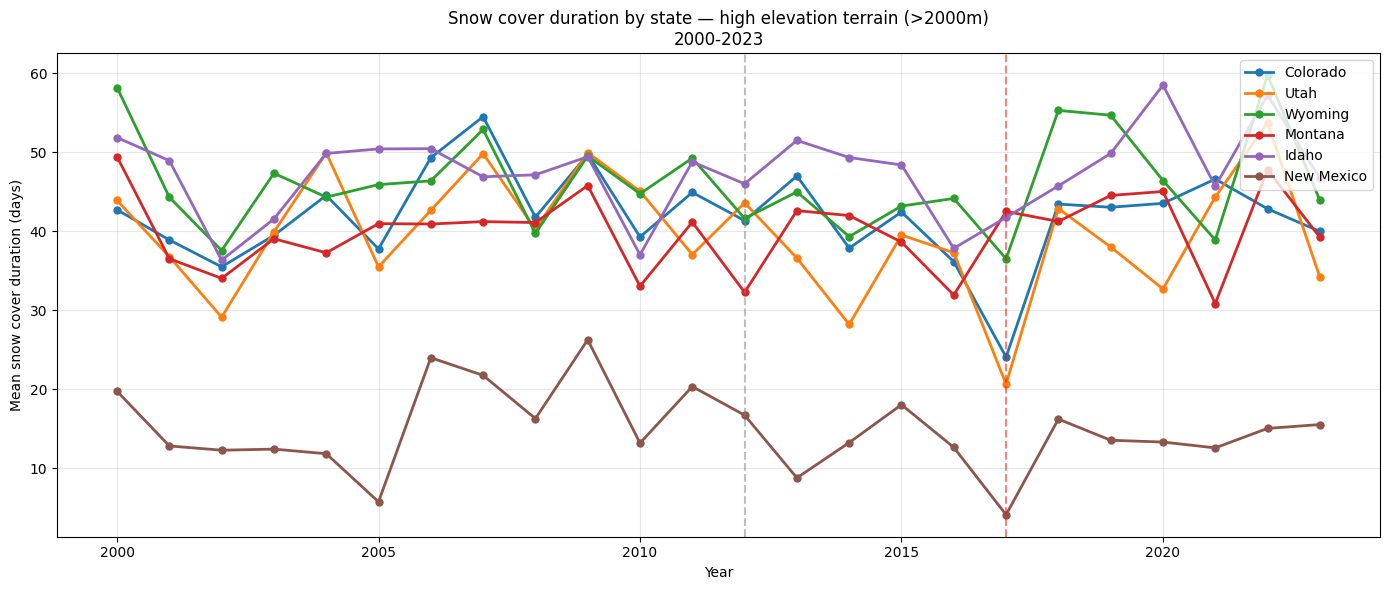

Cross-state correlations in snow cover duration:
state       colorado  idaho  montana  new_mexico   utah  wyoming
state                                                           
colorado       1.000  0.446    0.190       0.705  0.723    0.473
idaho          0.446  1.000    0.694       0.208  0.252    0.470
montana        0.190  0.694    1.000       0.229  0.067    0.624
new_mexico     0.705  0.208    0.229       1.000  0.562    0.419
utah           0.723  0.252    0.067       0.562  1.000    0.586
wyoming        0.473  0.470    0.624       0.419  0.586    1.000

Year-level summary (mean across all states):
state  all_states_mean
year                  
2000              44.3
2001              36.4
2002              30.8
2003              36.6
2004              39.6
2005              36.0
2006              42.3
2007              44.5
2008              37.7
2009              45.1
2010              35.4
2011              40.2
2012              36.9
2013              38.6
2014             

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Plot 1: Time series of snow duration by state
fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    'colorado':  '#1f77b4',
    'utah':      '#ff7f0e', 
    'wyoming':   '#2ca02c',
    'montana':   '#d62728',
    'idaho':     '#9467bd',
    'new_mexico':'#8c564b'
}

for state in state_names:
    state_data = snow_panel[snow_panel['state'] == state]
    ax.plot(state_data['year'], state_data['mean_snow_days'],
            'o-', label=state.replace('_', ' ').title(),
            color=colors[state], linewidth=2, markersize=5)

ax.set_xlabel("Year")
ax.set_ylabel("Mean snow cover duration (days)")
ax.set_title("Snow cover duration by state — high elevation terrain (>2000m)\n2000-2023")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.axvline(2012, color='gray', linestyle='--', alpha=0.5, label='2012 drought')
ax.axvline(2017, color='red',  linestyle='--', alpha=0.5, label='2017 low year')
plt.tight_layout()
plt.savefig(state_dir / "snow_duration_by_state.png", dpi=150)
plt.show()

# Plot 2: Correlation between states 
pivot = snow_panel.pivot(index='year', columns='state', 
                          values='mean_snow_days')

print("Cross-state correlations in snow cover duration:")
print(pivot.corr().round(3))

# Plot 3: Year-over-year anomalies
print("\nYear-level summary (mean across all states):")
pivot['all_states_mean'] = pivot.mean(axis=1)
print(pivot[['all_states_mean']].round(1).to_string())

# Key stats 
print("\nKey statistics per state:")
print(f"{'State':<12} {'Mean':>6} {'Min':>6} {'Max':>6} {'Std':>6}")
print("-" * 36)
for state in state_names:
    d = snow_panel[snow_panel['state'] == state]['mean_snow_days']
    print(f"{state:<12} {d.mean():>6.1f} {d.min():>6.1f} "
          f"{d.max():>6.1f} {d.std():>6.1f}")

Adding ONI signals

Western snow index vs ONI:
Year    Snow days    ONI
------------------------
2000         49.2   -1.6
2001         41.1   -0.5
2002         34.5    0.7
2003         41.5    0.5
2004         45.2    0.8
2005         42.1    0.7
2006         45.9    1.0
2007         49.0   -1.4
2008         42.0   -0.7
2009         48.9    1.7
2010         39.8    1.7
2011         44.2   -1.4
2012         41.0   -0.9
2013         44.5   -0.4
2014         39.3    0.6
2015         42.4    2.4
2016         37.5   -0.6
2017         33.1   -0.9
2018         45.7    0.8
2019         46.0    0.5
2020         45.2   -1.3
2021         41.3   -1.0
2022         52.3   -0.9
2023         40.8   -0.2

Western snow index vs ONI: r = -0.103


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

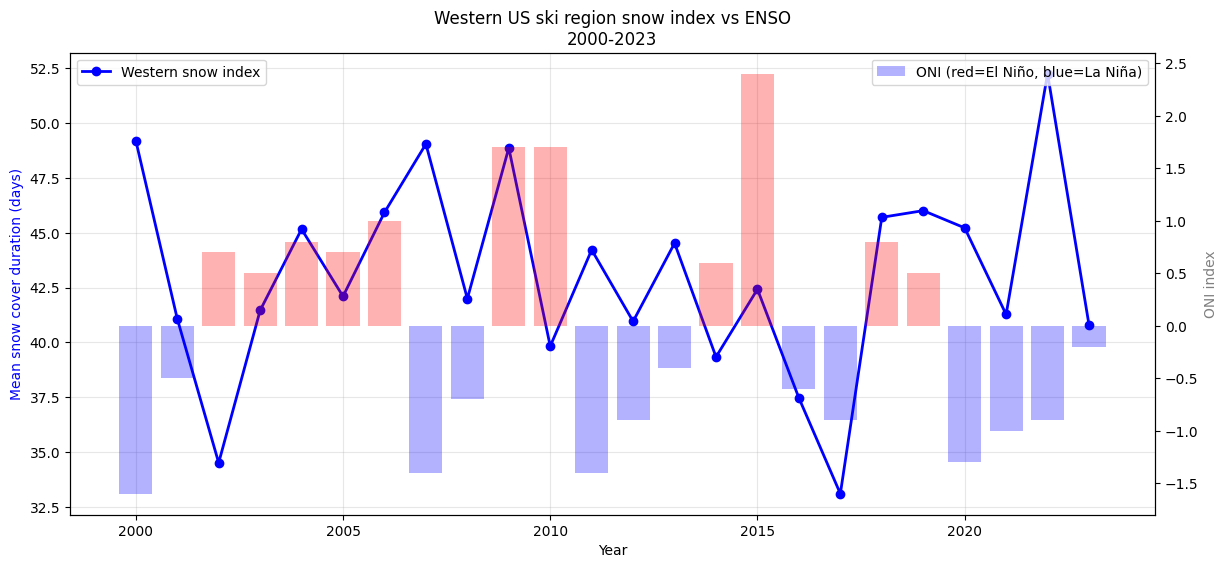

In [17]:
oni_full = {
    2000:-1.6, 2001:-0.5, 2002: 0.7, 2003: 0.5,
    2004: 0.8, 2005: 0.7, 2006: 1.0, 2007:-1.4,
    2008:-0.7, 2009: 1.7, 2010: 1.7, 2011:-1.4,
    2012:-0.9, 2013:-0.4, 2014: 0.6, 2015: 2.4,
    2016:-0.6, 2017:-0.9, 2018: 0.8, 2019: 0.5,
    2020:-1.3, 2021:-1.0, 2022:-0.9, 2023:-0.2
}

snow_panel['oni'] = snow_panel['year'].map(oni_full)

# Year-level mean (all states except New Mexico)
pivot = snow_panel.pivot(index='year', columns='state',
                          values='mean_snow_days')
pivot['western_mean'] = pivot[['colorado','utah','wyoming',
                                'montana','idaho']].mean(axis=1)
pivot['oni']          = pivot.index.map(oni_full)

print("Western snow index vs ONI:")
print(f"{'Year':<6} {'Snow days':>10} {'ONI':>6}")
print("-" * 24)
for year in years_full:
    row = pivot.loc[year]
    print(f"{year:<6} {row['western_mean']:>10.1f} {row['oni']:>6.1f}")

# Correlation of western mean with ONI
corr = pivot['western_mean'].corr(pivot['oni'])
print(f"\nWestern snow index vs ONI: r = {corr:.3f}")

# Plot snow index vs ONI
fig, ax1 = plt.subplots(figsize=(14, 6))

ax2 = ax1.twinx()
ax1.plot(pivot.index, pivot['western_mean'],
         'b-o', linewidth=2, markersize=6, label='Western snow index')
ax2.bar(pivot.index, pivot['oni'],
        alpha=0.3, color=['red' if x > 0 else 'blue' for x in pivot['oni']],
        label='ONI (red=El Niño, blue=La Niña)')

ax1.set_xlabel("Year")
ax1.set_ylabel("Mean snow cover duration (days)", color='blue')
ax2.set_ylabel("ONI index", color='gray')
ax1.set_title("Western US ski region snow index vs ENSO\n2000-2023")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

plt.tight_layout

Adding Satellite Account Winter Recreation GDP Value Added Data

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path

gdp_dir  = Path("/Users/evabenson/Files/thesis/snow_ml/gdp_data")
state_dir = Path("/Users/evabenson/Files/thesis/snow_ml/ski_snow_states")

# Load outdoor recreation GDP
gdp_raw = pd.read_csv(gdp_dir / "outdoor_rec.csv", skiprows=3)
gdp_raw = gdp_raw[pd.to_numeric(gdp_raw['GeoFIPS'], errors='coerce').notna()]
print("Raw GDP data:")
print(gdp_raw)

gdp_long = gdp_raw.melt(
    id_vars=['GeoFIPS', 'GeoName'],
    var_name='year',
    value_name='outdoor_rec_gdp'
)

gdp_long['year']            = gdp_long['year'].astype(int)
gdp_long['outdoor_rec_gdp'] = pd.to_numeric(gdp_long['outdoor_rec_gdp'],
                                              errors='coerce')

gdp_long['outdoor_rec_gdp_millions'] = gdp_long['outdoor_rec_gdp'] / 1000

state_map = {
    'Colorado':   'colorado',
    'Idaho':      'idaho',
    'Montana':    'montana',
    'New Mexico': 'new_mexico',
    'Utah':       'utah',
    'Wyoming':    'wyoming'
}
gdp_long['state'] = gdp_long['GeoName'].map(state_map)

print("\nGDP long format:")
print(gdp_long[['state','year','outdoor_rec_gdp_millions']].head(12))

panel = snow_panel.merge(
    gdp_long[['state','year','outdoor_rec_gdp_millions']],
    on=['state','year'],
    how='inner'
)

print(f"\nMerged panel shape: {panel.shape}")
print(f"Years covered: {panel['year'].min()} - {panel['year'].max()}")
print(f"States: {panel['state'].unique()}")
print(f"\nPanel preview:")
print(panel.pivot(index='year', columns='state',
                  values='outdoor_rec_gdp_millions').round(1))

Raw GDP data:
  GeoFIPS     GeoName      2012      2013       2014       2015       2016  \
0   08000    Colorado  772870.0  848508.0  1023835.0  1148105.0  1193478.0   
1   16000       Idaho   46782.0   49952.0    58364.0    63527.0    70310.0   
2   30000     Montana   31741.0   28647.0    34216.0    34957.0    37638.0   
3   35000  New Mexico   37496.0   39206.0    45473.0    49782.0    55615.0   
4   49000        Utah  238513.0  250415.0   288358.0   312302.0   350151.0   
5   56000     Wyoming   14731.0   15060.0    17409.0    18282.0    19458.0   

        2017       2018       2019      2020      2021       2022       2023  \
0  1195056.0  1225802.0  1229744.0  853936.0  988257.0  1433813.0  1562853.0   
1    78356.0    86831.0    95509.0   75729.0   87555.0   122267.0   140072.0   
2    41229.0    43274.0    47030.0   42554.0   53564.0    75386.0    82346.0   
3    62829.0    67433.0    75055.0   55082.0   63820.0    87987.0    97425.0   
4   387799.0   423757.0   453739.0  341

Running the Regression

Model 1: Snow only (no fixed effects)
  β_snow:    0.0062
  R²:        0.004
  Interpret: +1 snow day → 0.62% change in outdoor rec GDP

Model 2: Snow + state fixed effects
  β_snow:    0.0086
  R²:        0.952
  Interpret: +1 snow day → 0.86% change in outdoor rec GDP

Model 3: Snow + state FE + year FE (preferred)
  β_snow:    -0.0020
  R²:        0.996
  Interpret: +1 snow day → -0.20% change in outdoor rec GDP

  Mean outdoor rec GDP: $286.7M
  +1 snow day → $-0.6M change in outdoor rec GDP
  Across 6 states, 1 additional snow day ≈ $-3.5M total


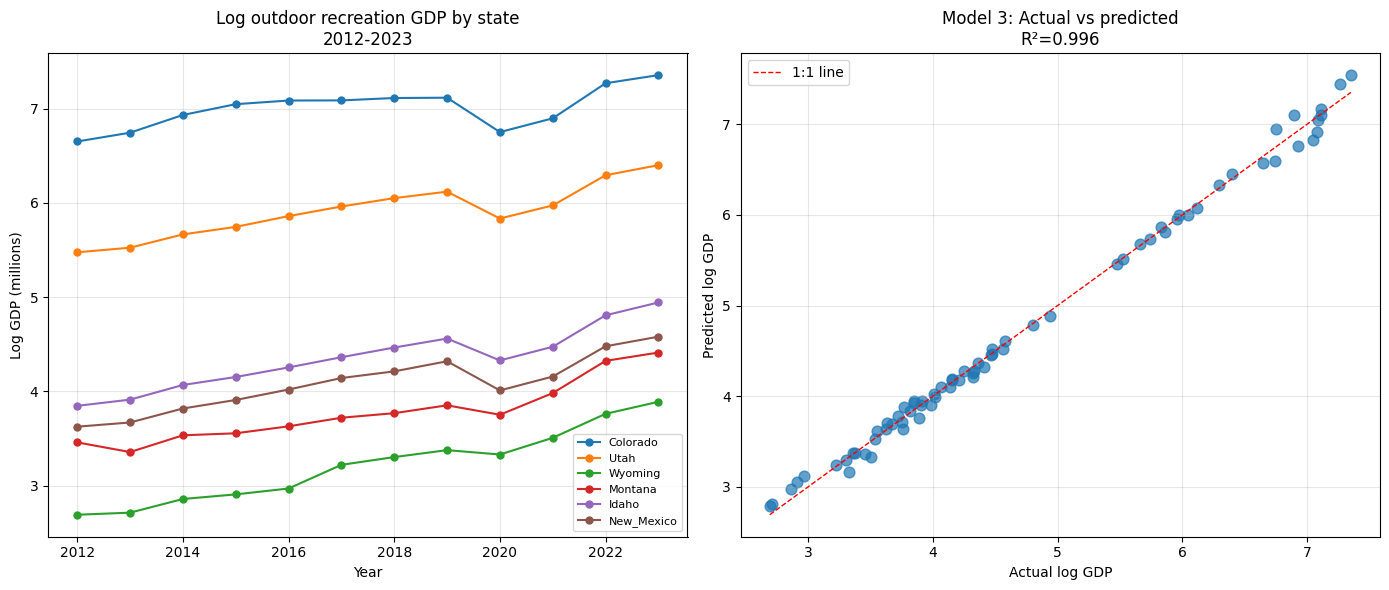

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Add log GDP 
panel['log_gdp'] = np.log(panel['outdoor_rec_gdp_millions'])

# Create fixed effects dummies
state_dummies = pd.get_dummies(panel['state'], prefix='state', drop_first=True)
year_dummies  = pd.get_dummies(panel['year'],  prefix='year',  drop_first=True)

# Model 1: Snow only (no fixed effects)
X1 = panel[['mean_snow_days']].values
y  = panel['log_gdp'].values

lr1 = LinearRegression().fit(X1, y)
print("Model 1: Snow only (no fixed effects)")
print(f"  β_snow:    {lr1.coef_[0]:.4f}")
print(f"  R²:        {r2_score(y, lr1.predict(X1)):.3f}")
print(f"  Interpret: +1 snow day → {lr1.coef_[0]*100:.2f}% change in outdoor rec GDP")

# Model 2: Snow + state fixed effects
X2 = pd.concat([panel[['mean_snow_days']], state_dummies], axis=1).values

lr2 = LinearRegression().fit(X2, y)
print("\nModel 2: Snow + state fixed effects")
print(f"  β_snow:    {lr2.coef_[0]:.4f}")
print(f"  R²:        {r2_score(y, lr2.predict(X2)):.3f}")
print(f"  Interpret: +1 snow day → {lr2.coef_[0]*100:.2f}% change in outdoor rec GDP")

# Model 3: Snow + state + year fixed effects 
X3 = pd.concat([panel[['mean_snow_days']],
                state_dummies, year_dummies], axis=1).values

lr3 = LinearRegression().fit(X3, y)
print("\nModel 3: Snow + state FE + year FE (preferred)")
print(f"  β_snow:    {lr3.coef_[0]:.4f}")
print(f"  R²:        {r2_score(y, lr3.predict(X3)):.3f}")
print(f"  Interpret: +1 snow day → {lr3.coef_[0]*100:.2f}% change in outdoor rec GDP")

mean_gdp = panel['outdoor_rec_gdp_millions'].mean()
dollar_impact = lr3.coef_[0] * mean_gdp
print(f"\n  Mean outdoor rec GDP: ${mean_gdp:.1f}M")
print(f"  +1 snow day → ${dollar_impact:.1f}M change in outdoor rec GDP")
print(f"  Across 6 states, 1 additional snow day ≈ ${dollar_impact*6:.1f}M total")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

y_pred3 = lr3.predict(X3)

for state in state_names:
    mask = panel['state'] == state
    axes[0].plot(panel[mask]['year'],
                 panel[mask]['log_gdp'],
                 'o-', label=state.title(), markersize=5)
axes[0].set_title("Log outdoor recreation GDP by state\n2012-2023")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Log GDP (millions)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Actual vs predicted
axes[1].scatter(y, y_pred3, alpha=0.7, s=60)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()],
             'r--', linewidth=1, label='1:1 line')
axes[1].set_xlabel("Actual log GDP")
axes[1].set_ylabel("Predicted log GDP")
axes[1].set_title(f"Model 3: Actual vs predicted\nR²={r2_score(y, y_pred3):.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(state_dir / "gdp_regression.png", dpi=150)
plt.show()

Demeaned snow variable (removes state size differences):
           snow_demeaned                                           
                   count mean   std    min   25%   50%   75%    max
state                                                              
colorado            12.0  0.0  6.09 -16.60 -1.24  1.94  2.77   6.30
idaho               12.0 -0.0  5.80 -10.37 -2.48 -0.66  2.05  10.28
montana             12.0 -0.0  5.52  -9.03 -2.85  1.73  3.20   7.91
new_mexico          12.0  0.0  3.77  -9.20 -0.69  0.12  2.39   4.73
utah                12.0 -0.0  8.45 -16.98 -3.83  0.01  5.41  16.08
wyoming             12.0 -0.0  7.20  -9.21 -4.69 -1.69  2.76  14.03

Within-state fixed effects regression:
  β_snow (demeaned):  0.0086
  R² (within):        0.030
  Interpret: when a state gets +1 snow day above its own average,
  outdoor rec GDP changes by 0.86%

  Mean GDP: $286.7M
  +1 snow day above average → $2.5M change in GDP


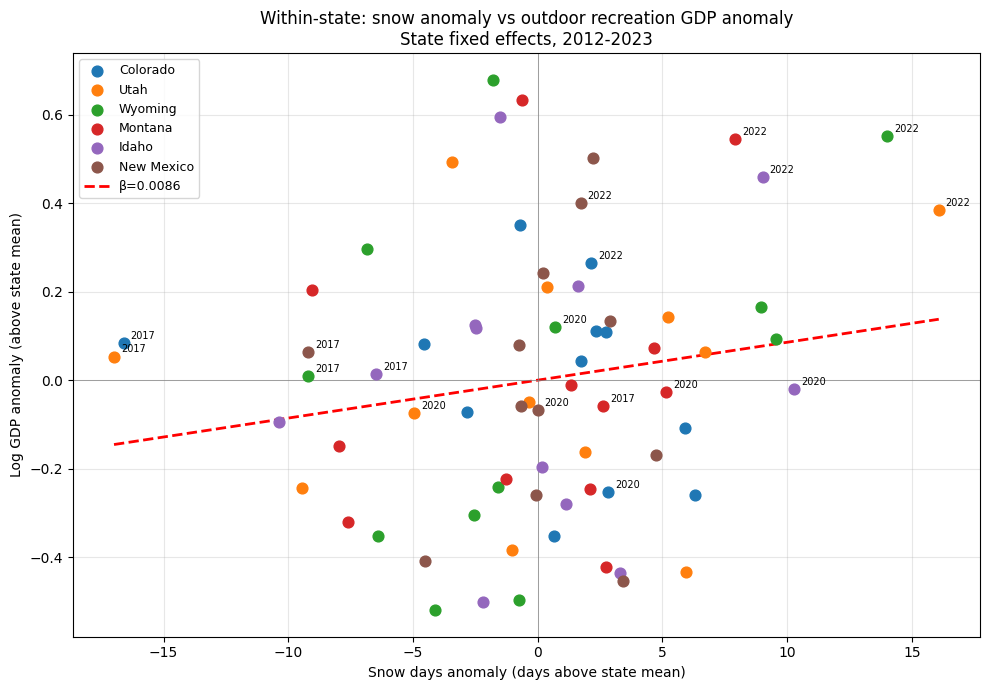

In [20]:
from sklearn.linear_model import LinearRegression
import numpy as np

panel['snow_demeaned'] = panel.groupby('state')['mean_snow_days'].transform(
    lambda x: x - x.mean()
)
panel['gdp_demeaned']  = panel.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

print("Demeaned snow variable (removes state size differences):")
print(panel.groupby('state')[['snow_demeaned']].describe().round(2))

# Within-state regression
X_fe = panel['snow_demeaned'].values.reshape(-1, 1)
y_fe = panel['gdp_demeaned'].values

lr_fe = LinearRegression().fit(X_fe, y_fe)

print(f"\nWithin-state fixed effects regression:")
print(f"  β_snow (demeaned):  {lr_fe.coef_[0]:.4f}")
print(f"  R² (within):        {r2_score(y_fe, lr_fe.predict(X_fe)):.3f}")
print(f"  Interpret: when a state gets +1 snow day above its own average,")
print(f"  outdoor rec GDP changes by {lr_fe.coef_[0]*100:.2f}%")

mean_gdp = panel['outdoor_rec_gdp_millions'].mean()
dollar   = lr_fe.coef_[0] * mean_gdp
print(f"\n  Mean GDP: ${mean_gdp:.1f}M")
print(f"  +1 snow day above average → ${dollar:.1f}M change in GDP")

fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {
    'colorado':'#1f77b4', 'utah':'#ff7f0e', 'wyoming':'#2ca02c',
    'montana':'#d62728',  'idaho':'#9467bd', 'new_mexico':'#8c564b'
}

for state in state_names:
    mask = panel['state'] == state
    ax.scatter(panel[mask]['snow_demeaned'],
               panel[mask]['gdp_demeaned'],
               label=state.replace('_',' ').title(),
               color=colors_map[state], s=60, zorder=3)

    for yr in [2017, 2020, 2022]:
        row = panel[mask & (panel['year'] == yr)]
        if not row.empty:
            ax.annotate(str(yr),
                       (row['snow_demeaned'].values[0],
                        row['gdp_demeaned'].values[0]),
                       textcoords="offset points",
                       xytext=(5,3), fontsize=7)

x_line = np.linspace(panel['snow_demeaned'].min(),
                     panel['snow_demeaned'].max(), 100)
ax.plot(x_line, lr_fe.coef_[0]*x_line + lr_fe.intercept_,
        'r--', linewidth=2, label=f'β={lr_fe.coef_[0]:.4f}')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel("Snow days anomaly (days above state mean)")
ax.set_ylabel("Log GDP anomaly (above state mean)")
ax.set_title("Within-state: snow anomaly vs outdoor recreation GDP anomaly\n"
             "State fixed effects, 2012-2023")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(state_dir / "within_state_regression.png", dpi=150)
plt.show()

Snow Trend Model

Snow cover duration trend (2000-2023):
  Slope:     0.006 days/year
  R²:        0.000
  p-value:   0.965
  Total trend 2000-2023: 0.1 days
  No statistically significant trend detected

Projected snow duration:
  2030: 43.1 days (range: 34.4 - 51.9)
  2040: 43.2 days (range: 34.4 - 51.9)
  2050: 43.3 days (range: 34.5 - 52.0)


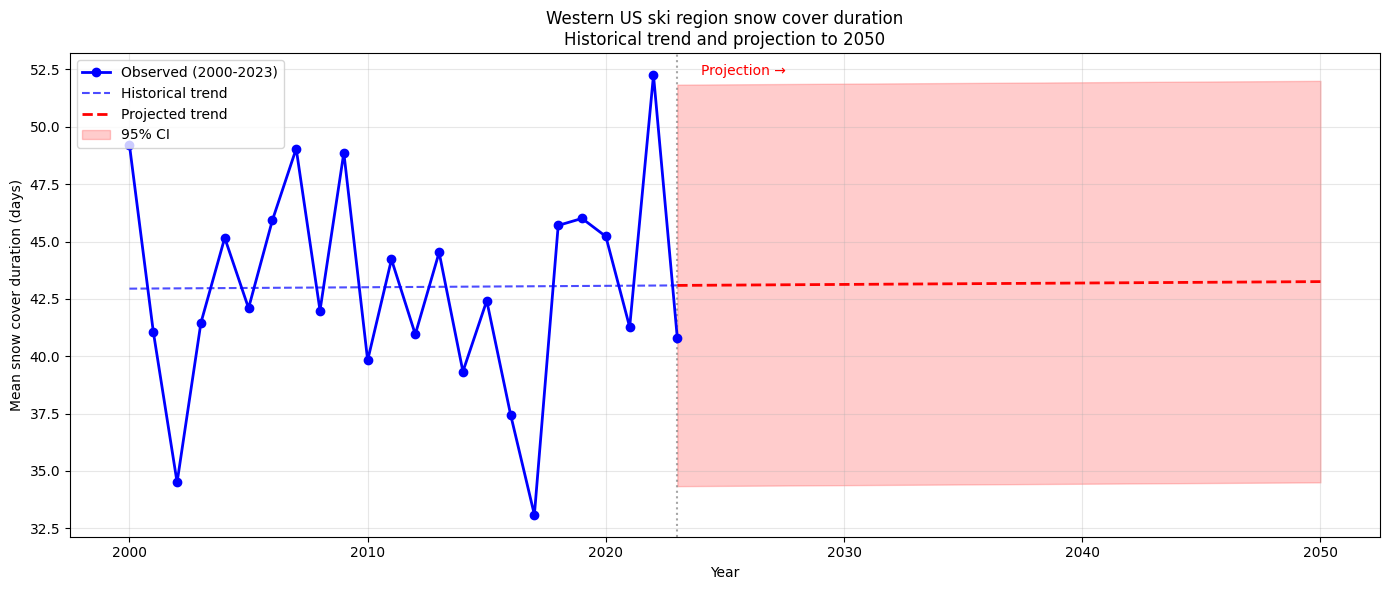

In [21]:
from sklearn.linear_model import LinearRegression
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Compute western mean snow index
pivot = snow_panel.pivot(index='year', columns='state',
                          values='mean_snow_days')
# Exclude New Mexico — outlier
pivot['western_mean'] = pivot[['colorado','utah','wyoming',
                                'montana','idaho']].mean(axis=1)

years_arr  = pivot.index.values.reshape(-1, 1)
snow_arr   = pivot['western_mean'].values

lr_trend = LinearRegression().fit(years_arr, snow_arr)
slope     = lr_trend.coef_[0]
intercept = lr_trend.intercept_

slope_stat, intercept_stat, r, p, se = stats.linregress(
    pivot.index.values, snow_arr
)

print("Snow cover duration trend (2000-2023):")
print(f"  Slope:     {slope:.3f} days/year")
print(f"  R²:        {r**2:.3f}")
print(f"  p-value:   {p:.3f}")
print(f"  Total trend 2000-2023: {slope*23:.1f} days")

if p < 0.05:
    print("  *** Statistically significant trend ***")
elif p < 0.10:
    print("  * Marginally significant trend (p<0.10)")
else:
    print("  No statistically significant trend detected")

# Project to 2050
future_years = np.arange(2000, 2051)
snow_projected = lr_trend.predict(future_years.reshape(-1, 1))

n    = len(pivot)
se_snow = np.std(snow_arr - lr_trend.predict(years_arr))
ci   = 1.96 * se_snow

print(f"\nProjected snow duration:")
for yr in [2030, 2040, 2050]:
    proj = lr_trend.predict([[yr]])[0]
    print(f"  {yr}: {proj:.1f} days "
          f"(range: {proj-ci:.1f} - {proj+ci:.1f})")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(pivot.index, snow_arr, 'bo-', linewidth=2,
        markersize=6, label='Observed (2000-2023)', zorder=3)

hist_years = np.arange(2000, 2024)
ax.plot(hist_years,
        lr_trend.predict(hist_years.reshape(-1,1)),
        'b--', linewidth=1.5, alpha=0.7, label='Historical trend')

proj_years = np.arange(2023, 2051)
proj_vals  = lr_trend.predict(proj_years.reshape(-1,1))
ax.plot(proj_years, proj_vals, 'r--', linewidth=2,
        label='Projected trend')
ax.fill_between(proj_years,
                proj_vals - ci,
                proj_vals + ci,
                alpha=0.2, color='red', label='95% CI')

ax.axvline(2023, color='gray', linestyle=':', alpha=0.7)
ax.text(2024, snow_arr.max(), 'Projection →', fontsize=10, color='red')
ax.set_xlabel("Year")
ax.set_ylabel("Mean snow cover duration (days)")
ax.set_title("Western US ski region snow cover duration\nHistorical trend and projection to 2050")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(state_dir / "snow_trend_projection.png", dpi=150)
plt.show()

Snow cover duration --> Outdoor recreation GDP

  β (snow days):  0.0086
  R²:             0.030
  p-value:        0.146
  Std error:      0.0058
  Not statistically significant

  Mean outdoor rec GDP per state: $286.7M
  +1 snow day → +0.86% GDP per state
  +1 snow day → +$2.5M per state
  +1 snow day → +$12.3M across 5 states

Scenario                               Per state     5 states
------------------------------------------------------------
  Average year (baseline)           $     +0.0M $     +0.0M
  Good year (+5 snow days)          $    +12.3M $    +61.3M
  Great year (+10 snow days)        $    +24.5M $   +122.7M
  Poor year (-5 snow days)          $    -12.3M $    -61.3M
  Bad year like 2017 (-10d)         $    -24.5M $   -122.7M

Climate warming scenarios (using β_tmin = -2.97 days/°C):
Warming          Snow change  GDP impact (5 states)
--------------------------------------------------
  +1°C                -3.0d   $          -36.4M
  +2°C                -5.9d   $    

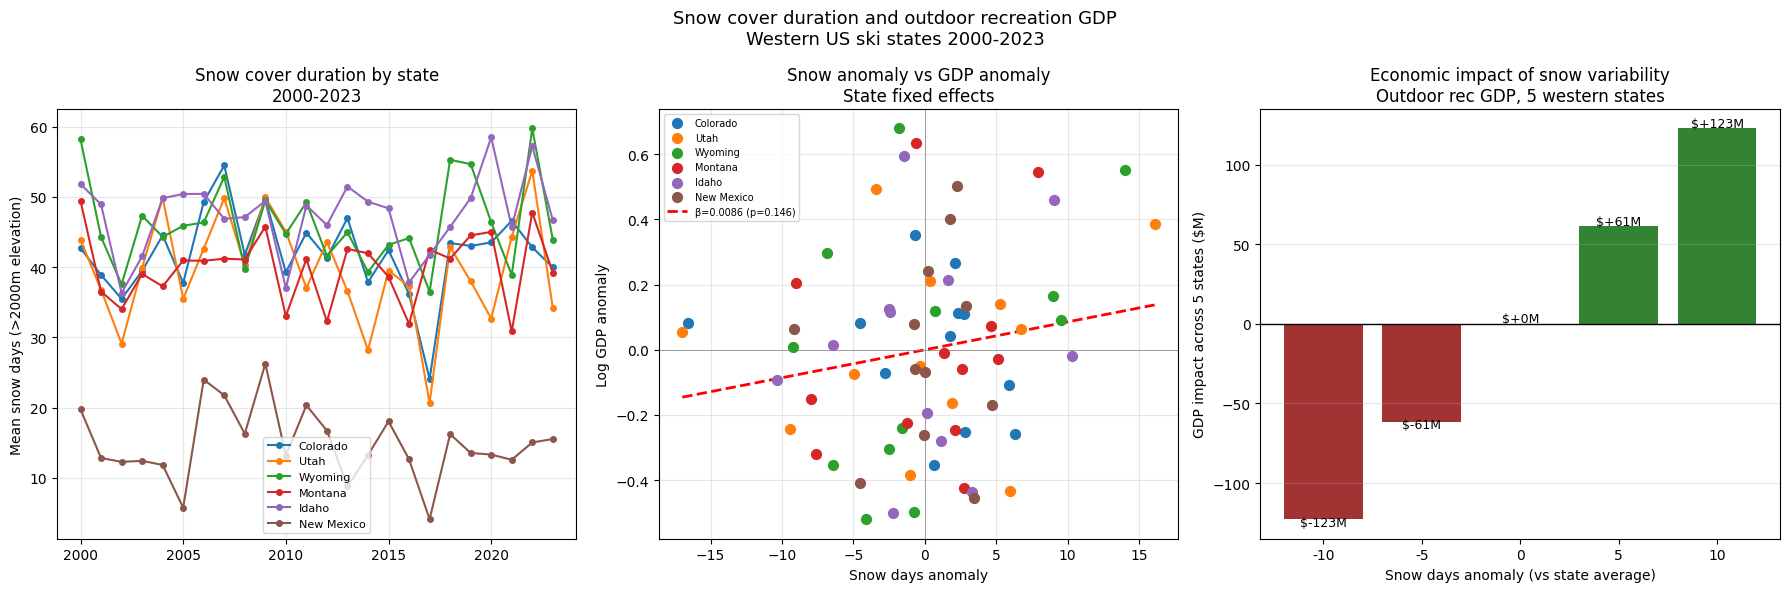

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# SNOW COVER --> OUTDOOR RECREATION GDP

panel['snow_demeaned'] = panel.groupby('state')['mean_snow_days'].transform(
    lambda x: x - x.mean()
)
panel['gdp_demeaned'] = panel.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

X = panel['snow_demeaned'].values
y = panel['gdp_demeaned'].values

slope, intercept, r, p, se = stats.linregress(X, y)

print("Snow cover duration --> Outdoor recreation GDP")
print(f"\n  β (snow days):  {slope:.4f}")
print(f"  R²:             {r**2:.3f}")
print(f"  p-value:        {p:.3f}")
print(f"  Std error:      {se:.4f}")

if p < 0.05:
    print("  *** Statistically significant at 5% level ***")
elif p < 0.10:
    print("  * Significant at 10% level")
else:
    print("  Not statistically significant")

mean_gdp = panel['outdoor_rec_gdp_millions'].mean()
dollar_per_day_per_state = slope * mean_gdp
dollar_per_day_all_states = dollar_per_day_per_state * 5

print(f"\n  Mean outdoor rec GDP per state: ${mean_gdp:.1f}M")
print(f"  +1 snow day → +{slope*100:.2f}% GDP per state")
print(f"  +1 snow day → +${dollar_per_day_per_state:.1f}M per state")
print(f"  +1 snow day → +${dollar_per_day_all_states:.1f}M across 5 states")

print(f"\n{'Scenario':<35} {'Per state':>12} {'5 states':>12}")
print("-" * 60)

scenarios = [
    ("Average year (baseline)",      0),
    ("Good year (+5 snow days)",     5),
    ("Great year (+10 snow days)",  10),
    ("Poor year (-5 snow days)",    -5),
    ("Bad year like 2017 (-10d)", -10),
]

for label, delta in scenarios:
    per_state = slope * delta * mean_gdp
    total     = per_state * 5
    print(f"  {label:<33} ${per_state:>+9.1f}M ${total:>+9.1f}M")

print(f"\nClimate warming scenarios (using β_tmin = -2.97 days/°C):")
print(f"{'Warming':<15} {'Snow change':>12} {'GDP impact (5 states)':>22}")
print("-" * 50)

beta_tmin = -2.97
for warming in [1.0, 2.0, 3.0, 4.0]:
    snow_chg = beta_tmin * warming
    gdp_chg  = slope * snow_chg * mean_gdp * 5
    print(f"  +{warming:.0f}°C          {snow_chg:>+10.1f}d "
          f"  ${gdp_chg:>+15.1f}M")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors_map = {
    'colorado':'#1f77b4', 'utah':'#ff7f0e', 'wyoming':'#2ca02c',
    'montana':'#d62728',  'idaho':'#9467bd', 'new_mexico':'#8c564b'
}
for state in state_names:
    d = snow_panel[snow_panel['state']==state]
    axes[0].plot(d['year'], d['mean_snow_days'],
                 'o-', label=state.replace('_',' ').title(),
                 color=colors_map[state], linewidth=1.5, markersize=4)
axes[0].set_title("Snow cover duration by state\n2000-2023")
axes[0].set_ylabel("Mean snow days (>2000m elevation)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for state in state_names:
    mask = panel['state'] == state
    axes[1].scatter(panel[mask]['snow_demeaned'],
                    panel[mask]['gdp_demeaned'],
                    label=state.replace('_',' ').title(),
                    color=colors_map[state], s=50, zorder=3)

x_line = np.linspace(X.min(), X.max(), 100)
axes[1].plot(x_line, slope*x_line + intercept,
             'r--', linewidth=2, label=f'β={slope:.4f} (p={p:.3f})')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel("Snow days anomaly")
axes[1].set_ylabel("Log GDP anomaly")
axes[1].set_title("Snow anomaly vs GDP anomaly\nState fixed effects")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

delta_snows = [-10, -5, 0, 5, 10]
gdp_impacts = [slope * d * mean_gdp * 5 for d in delta_snows]
bar_colors  = ['darkred' if x < 0 else 'darkgreen' if x > 0
               else 'gray' for x in gdp_impacts]

bars = axes[2].bar([str(d) for d in delta_snows],
                   gdp_impacts, color=bar_colors, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_xlabel("Snow days anomaly (vs state average)")
axes[2].set_ylabel("GDP impact across 5 states ($M)")
axes[2].set_title("Economic impact of snow variability\nOutdoor rec GDP, 5 western states")
axes[2].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, gdp_impacts):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (1 if val >= 0 else -4),
                 f'${val:+.0f}M', ha='center', fontsize=9)

plt.suptitle("Snow cover duration and outdoor recreation GDP\n"
             "Western US ski states 2000-2023", fontsize=13)
plt.tight_layout()
plt.savefig(state_dir / "final_results.png", dpi=150)
plt.show()

In [23]:
# Drop New Mexico (low snow, different climate) 
panel_clean = panel[
    (panel['state'] != 'new_mexico') &
    (panel['year'] != 2020)
].copy()

panel_clean['snow_demeaned'] = panel_clean.groupby('state')['mean_snow_days'].transform(
    lambda x: x - x.mean()
)
panel_clean['gdp_demeaned'] = panel_clean.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

X_clean = panel_clean['snow_demeaned'].values
y_clean = panel_clean['gdp_demeaned'].values

slope_c, intercept_c, r_c, p_c, se_c = stats.linregress(X_clean, y_clean)

print("Clean sample (no NM, no 2020):")
print(f"  β:       {slope_c:.4f}")
print(f"  R²:      {r_c**2:.3f}")
print(f"  p-value: {p_c:.3f}")

Clean sample (no NM, no 2020):
  β:       0.0096
  R²:      0.039
  p-value: 0.147


In [24]:
from pathlib import Path

# Check existing SNODAS files
snodas_base = Path("/Users/evabenson/Files/thesis/snow_ml/gee/snodas")

tar_files = sorted(snodas_base.glob("*.tar"))
print(f"Existing SNODAS files: {len(tar_files)}")
for f in tar_files[:5]:
    print(f"  {f.name}")
print("  ...")
for f in tar_files[-3:]:
    print(f"  {f.name}")

print(f"\nDate range: {tar_files[0].name} to {tar_files[-1].name}")

Existing SNODAS files: 219
  SNODAS_20121101.tar
  SNODAS_20121108.tar
  SNODAS_20121115.tar
  SNODAS_20121122.tar
  SNODAS_20121129.tar
  ...
  SNODAS_20220314.tar
  SNODAS_20220321.tar
  SNODAS_20220328.tar

Date range: SNODAS_20121101.tar to SNODAS_20220328.tar


In [25]:
snodas_base = Path("/Users/evabenson/Files/thesis/snow_ml/gee/snodas")
tar_files   = sorted(snodas_base.glob("SNODAS_*.tar"))
test_file   = tar_files[0]

print(f"Testing with: {test_file.name}")
print("\nTesting extraction for each state...")

for state in STATE_BOUNDS:
    clip = read_snodas_state(test_file, state)
    if clip is not None:
        print(f"  {state:<12} shape={clip.shape}, "
              f"depth range={np.nanmin(clip):.0f}-{np.nanmax(clip):.0f} cm, "
              f"mean={np.nanmean(clip):.0f} cm")
    else:
        print(f"  {state:<12} FAILED — depth file not found in tar")

Testing with: SNODAS_20121101.tar

Testing extraction for each state...
  colorado     shape=(482, 840), depth range=0-39 cm, mean=0 cm
  utah         shape=(602, 600), depth range=0-30 cm, mean=0 cm
  wyoming      shape=(483, 840), depth range=0-98 cm, mean=2 cm
  montana      shape=(558, 1440), depth range=0-81 cm, mean=1 cm
  idaho        shape=(842, 742), depth range=0-37 cm, mean=1 cm


In [26]:
from datetime import date

def get_water_year(d):
    return d.year if d.month >= 10 else d.year - 1


def get_state_mean_depth(tar_path, state):
    """
    Extract mean snow depth (cm) for high elevation pixels
    in a state from a SNODAS tar file.
    Returns scalar mean value.
    """
    clip = read_snodas_state(tar_path, state)
    if clip is None:
        return np.nan

    clip = np.where(clip < 0, np.nan, clip)

    return np.nanmean(clip)

records   = []
tar_files = sorted(snodas_base.glob("SNODAS_*.tar"))

print(f"Processing {len(tar_files)} SNODAS files x {len(STATE_BOUNDS)} states...")

for tar_path in tar_files:
    datestr = tar_path.stem.replace("SNODAS_", "")
    d       = date(int(datestr[:4]), int(datestr[4:6]), int(datestr[6:8]))
    doy     = d.timetuple().tm_yday
    wy      = get_water_year(d)

    for state in STATE_BOUNDS:
        mean_depth = get_state_mean_depth(tar_path, state)

        records.append({
            'date':       str(d),
            'year':       d.year,
            'doy':        doy,
            'water_year': wy,
            'state':      state,
            'depth_cm':   mean_depth
        })

    print(f"  {d}: done")

depth_panel = pd.DataFrame(records)
print(f"\nDepth panel shape: {depth_panel.shape}")
print(f"\nMean depth by state (cm):")
print(depth_panel.groupby('state')['depth_cm'].describe().round(1))

Processing 219 SNODAS files x 5 states...
  2012-11-01: done
  2012-11-08: done
  2012-11-15: done
  2012-11-22: done
  2012-11-29: done
  2012-12-06: done
  2012-12-13: done
  2012-12-27: done
  2013-01-03: done
  2013-01-10: done
  2013-01-17: done
  2013-01-24: done
  2013-01-31: done
  2013-02-07: done
  2013-02-14: done
  2013-02-21: done
  2013-02-28: done
  2013-03-07: done
  2013-03-14: done
  2013-03-21: done
  2013-03-28: done
  2013-11-01: done
  2013-11-08: done
  2013-11-15: done
  2013-11-22: done
  2013-11-29: done
  2013-12-06: done
  2013-12-13: done
  2013-12-20: done
  2013-12-27: done
  2014-01-03: done
  2014-01-10: done
  2014-01-17: done
  2014-01-24: done
  2014-01-31: done
  2014-02-07: done
  2014-02-14: done
  2014-02-21: done
  2014-02-28: done
  2014-03-07: done
  2014-03-14: done
  2014-03-21: done
  2014-03-28: done
  2014-11-01: done
  2014-11-08: done
  2014-11-15: done
  2014-11-22: done
  2014-11-29: done
  2014-12-06: done
  2014-12-13: done
  2014-1

Merged depth model dataset: (1095, 7)
Missing snow duration: 0
      state        date  doy  mean_snow_days  depth_cm
0  colorado  2012-11-01  306       46.980950  0.369121
1      utah  2012-11-01  306       36.593237  0.072620
2   wyoming  2012-11-01  306       44.970539  1.982637
3   montana  2012-11-01  306       42.595860  0.614254
4     idaho  2012-11-01  306       51.481079  0.543065
5  colorado  2012-11-08  313       46.980950  0.163727
6      utah  2012-11-08  313       36.593237  0.105914
7   wyoming  2012-11-08  313       44.970539  1.524113
8   montana  2012-11-08  313       42.595860  0.211041
9     idaho  2012-11-08  313       51.481079  0.082487

Train samples: 110  (winter 2020-2021)
Test samples:  110   (winter 2021-2022)

Snow depth model coefficients:
  doy                       -0.0482
  mean_snow_days            -0.3084
  state_idaho               15.9755
  state_montana             0.3476
  state_utah                -7.2009
  state_wyoming             -0.4226
  int

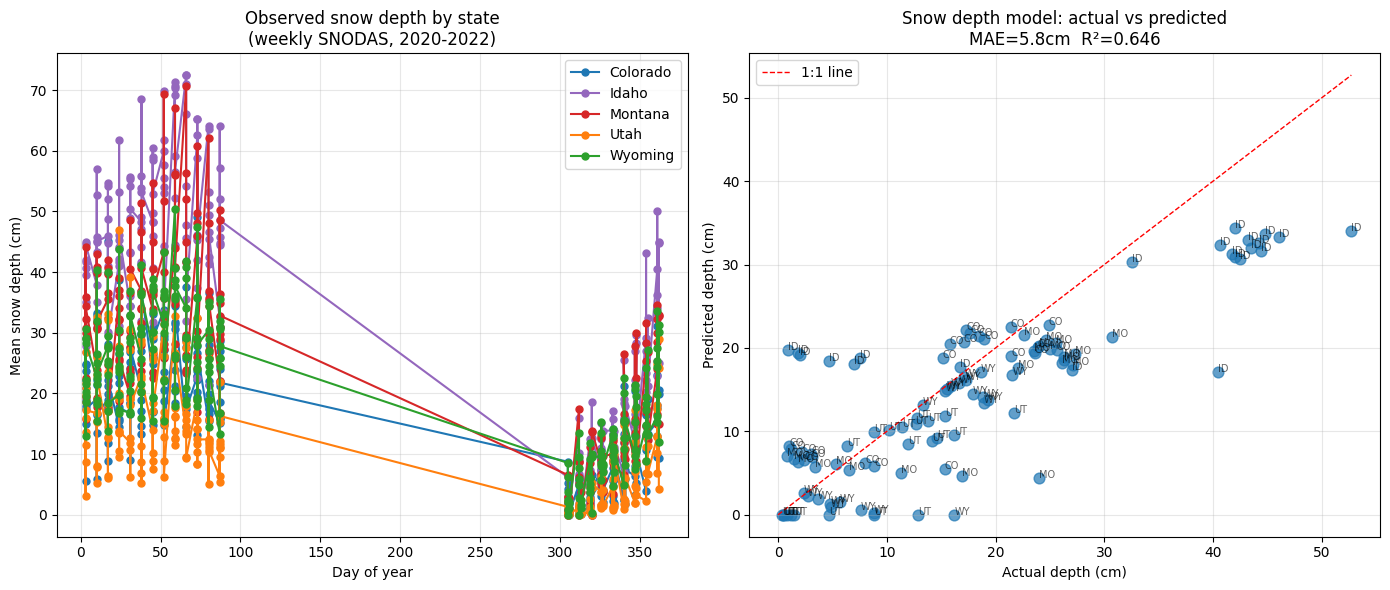

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats

# Get snow duration per state per water year
snow_by_wy = snow_panel.copy()
snow_by_wy['water_year'] = snow_by_wy['year'] - 1

depth_model_df = depth_panel.merge(
    snow_by_wy[['state','water_year','mean_snow_days']],
    on=['state','water_year'],
    how='left'
)

state_dummies = pd.get_dummies(depth_model_df['state'],
                                prefix='state', drop_first=True)

print(f"Merged depth model dataset: {depth_model_df.shape}")
print(f"Missing snow duration: {depth_model_df['mean_snow_days'].isna().sum()}")
print(depth_model_df[['state','date','doy',
                       'mean_snow_days','depth_cm']].head(10))


feature_df = pd.concat([
    depth_model_df[['doy','mean_snow_days']],
    state_dummies
], axis=1).dropna()

target = depth_model_df.loc[feature_df.index, 'depth_cm']

X = feature_df.values
y = target.values

wy = depth_model_df.loc[feature_df.index, 'water_year']
train_mask = wy == 2020   
test_mask  = wy == 2021   

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"\nTrain samples: {len(X_train)}  (winter 2020-2021)")
print(f"Test samples:  {len(X_test)}   (winter 2021-2022)")

lr_depth_state = LinearRegression()
lr_depth_state.fit(X_train, y_train)

feature_names = ['doy', 'mean_snow_days'] + list(state_dummies.columns)
print("\nSnow depth model coefficients:")
for feat, coef in zip(feature_names, lr_depth_state.coef_):
    print(f"  {feat:<25} {coef:.4f}")
print(f"  {'intercept':<25} {lr_depth_state.intercept_:.4f}")

y_pred = lr_depth_state.predict(X_test)
y_pred = np.clip(y_pred, 0, None)

print(f"\nTest MAE: {mean_absolute_error(y_test, y_pred):.1f} cm")
print(f"Test R²:  {r2_score(y_test, y_pred):.3f}")

# Predict depth for future scenario
print("\nPredicted mean depth by state on Jan 15 (DOY 15):")
print(f"{'State':<12} {'Normal year':>12} {'Bad year (-10d)':>16} {'Good year (+10d)':>17}")
print("-" * 58)

state_list = ['colorado','idaho','montana','utah','wyoming']
for state in state_list:
    row_base = {'doy': 15, 'mean_snow_days': 43.0}
    for col in state_dummies.columns:
        row_base[col] = 1 if col == f'state_{state}' else 0

    row_bad  = row_base.copy()
    row_bad['mean_snow_days']  = 33.0   

    row_good = row_base.copy()
    row_good['mean_snow_days'] = 53.0   

    pred_normal = max(0, lr_depth_state.predict(
        [list(row_base.values())])[0])
    pred_bad    = max(0, lr_depth_state.predict(
        [list(row_bad.values())])[0])
    pred_good   = max(0, lr_depth_state.predict(
        [list(row_good.values())])[0])

    print(f"  {state:<12} {pred_normal:>10.1f}cm "
          f"{pred_bad:>14.1f}cm {pred_good:>15.1f}cm")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {
    'colorado':'#1f77b4', 'utah':'#ff7f0e', 'wyoming':'#2ca02c',
    'montana':'#d62728',  'idaho':'#9467bd'
}
for state in state_list:
    mask = depth_panel['state'] == state
    d    = depth_panel[mask].sort_values('doy')
    axes[0].plot(d['doy'], d['depth_cm'],
                 'o-', label=state.title(),
                 color=colors_map[state], linewidth=1.5, markersize=5)

axes[0].set_xlabel("Day of year")
axes[0].set_ylabel("Mean snow depth (cm)")
axes[0].set_title("Observed snow depth by state\n(weekly SNODAS, 2020-2022)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred, alpha=0.7, s=60)
axes[1].plot([0, y_test.max()], [0, y_test.max()],
             'r--', linewidth=1, label='1:1 line')
for i, (yt, yp) in enumerate(zip(y_test, y_pred)):
    state = depth_model_df[test_mask]['state'].iloc[i]
    axes[1].annotate(state[:2].upper(),
                     (yt, yp), fontsize=7, alpha=0.6)
axes[1].set_xlabel("Actual depth (cm)")
axes[1].set_ylabel("Predicted depth (cm)")
axes[1].set_title(f"Snow depth model: actual vs predicted\n"
                  f"MAE={mean_absolute_error(y_test,y_pred):.1f}cm  "
                  f"R²={r2_score(y_test,y_pred):.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(state_dir / "state_depth_model.png", dpi=150)
plt.show()

In [28]:
# Compute annual mean depth per state 
annual_depth = depth_panel.groupby(['state','water_year'])['depth_cm'].mean().reset_index()
annual_depth.columns = ['state','year','mean_depth_cm']

annual_depth['gdp_year'] = annual_depth['year'] + 1

print("Annual mean depth per state:")
print(annual_depth.pivot(index='gdp_year', columns='state', 
                          values='mean_depth_cm').round(1))

depth_gdp = annual_depth.merge(
    panel[['state','year','outdoor_rec_gdp_millions','log_gdp']],
    left_on  = ['state','gdp_year'],
    right_on = ['state','year'],
    how='inner'
)

print(f"\nMerged depth-GDP dataset: {depth_gdp.shape}")
print(depth_gdp[['state','gdp_year','mean_depth_cm',
                  'outdoor_rec_gdp_millions']].to_string(index=False))

Annual mean depth per state:
state     colorado  idaho  montana  utah  wyoming
gdp_year                                         
2013          15.7   36.1     28.3  15.7     21.5
2014          20.9   40.5     33.3  13.3     26.8
2015          14.7   24.9     19.4   6.7     18.2
2016          19.9   35.1     22.9  15.2     18.6
2017          20.2   41.2     27.9  18.6     27.7
2018           9.4   38.0     36.8   6.6     22.7
2019          21.1   34.7     24.7  16.1     21.8
2020          18.5   33.3     22.0  13.3     22.7
2021          13.9   30.2     19.1   7.4     15.9
2022          13.9   30.4     18.3   9.2     12.9

Merged depth-GDP dataset: (50, 7)
   state  gdp_year  mean_depth_cm  outdoor_rec_gdp_millions
colorado      2013      15.675953                   848.508
colorado      2014      20.880254                  1023.835
colorado      2015      14.675600                  1148.105
colorado      2016      19.890734                  1193.478
colorado      2017      20.189051   

In [29]:
import urllib.request
from datetime import date, timedelta

snodas_base = Path("/Users/evabenson/Files/thesis/snow_ml/gee/snodas")

sample_dates = []
for start_year in range(2012, 2020):
    d_start = date(start_year, 11, 1)
    d_end   = date(start_year + 1, 3, 31)
    d = d_start
    while d <= d_end:
        sample_dates.append(d)
        d += timedelta(days=7)

print(f"Total dates to download: {len(sample_dates)}")
print(f"Date range: {sample_dates[0]} to {sample_dates[-1]}")

def download_snodas(target_date):
    yyyy  = target_date.strftime("%Y")
    mm    = target_date.strftime("%m")
    mon   = target_date.strftime("%b")
    mmm   = f"{mm}_{mon}"
    ddstr = target_date.strftime("%Y%m%d")
    tar_name  = f"SNODAS_{ddstr}.tar"
    local_tar = snodas_base / tar_name

    if local_tar.exists():
        return True

    url = (f"https://noaadata.apps.nsidc.org/NOAA/G02158/masked/"
           f"{yyyy}/{mmm}/{tar_name}")
    try:
        print(f"  Downloading {ddstr}...", end=" ")
        urllib.request.urlretrieve(url, local_tar)
        print("done")
        return True
    except Exception as e:
        print(f"FAILED: {e}")
        return False

for d in sample_dates:
    download_snodas(d)

print(f"\nTotal SNODAS files now: {len(list(snodas_base.glob('*.tar')))}")

Total dates to download: 176
Date range: 2012-11-01 to 2020-03-27

Total SNODAS files now: 219


In [30]:
tar_files = sorted(snodas_base.glob("SNODAS_*.tar"))
print(f"Total SNODAS files: {len(tar_files)}")
print(f"Date range: {tar_files[0].name} to {tar_files[-1].name}")

# Rebuild depth panel w/ SNODAS files
records = []

for tar_path in tar_files:
    datestr = tar_path.stem.replace("SNODAS_", "")
    d       = date(int(datestr[:4]), int(datestr[4:6]), int(datestr[6:8]))
    doy     = d.timetuple().tm_yday
    wy      = get_water_year(d)

    for state in STATE_BOUNDS:
        mean_depth = get_state_mean_depth(tar_path, state)
        records.append({
            'date':       str(d),
            'year':       d.year,
            'doy':        doy,
            'water_year': wy,
            'state':      state,
            'depth_cm':   mean_depth
        })

    print(f"  {d}: done")

depth_panel_full = pd.DataFrame(records)
print(f"\nFull depth panel shape: {depth_panel_full.shape}")

# Annual mean depth per state per water year
annual_depth_full = depth_panel_full.groupby(
    ['state','water_year'])['depth_cm'].mean().reset_index()
annual_depth_full.columns = ['state','year','mean_depth_cm']
annual_depth_full['gdp_year'] = annual_depth_full['year'] + 1

print("\nAnnual mean depth per state (cm):")
print(annual_depth_full.pivot(index='gdp_year', columns='state',
                               values='mean_depth_cm').round(1))

depth_gdp_full = annual_depth_full.merge(
    panel[['state','year','outdoor_rec_gdp_millions','log_gdp']],
    left_on  = ['state','gdp_year'],
    right_on = ['state','year'],
    how='inner'
)

print(f"\nMerged depth-GDP dataset: {depth_gdp_full.shape}")
print(f"Years covered: {depth_gdp_full['gdp_year'].min()} - "
      f"{depth_gdp_full['gdp_year'].max()}")
print(f"Observations per state: {depth_gdp_full.groupby('state').size().to_dict()}")

Total SNODAS files: 219
Date range: SNODAS_20121101.tar to SNODAS_20220328.tar
  2012-11-01: done
  2012-11-08: done
  2012-11-15: done
  2012-11-22: done
  2012-11-29: done
  2012-12-06: done
  2012-12-13: done
  2012-12-27: done
  2013-01-03: done
  2013-01-10: done
  2013-01-17: done
  2013-01-24: done
  2013-01-31: done
  2013-02-07: done
  2013-02-14: done
  2013-02-21: done
  2013-02-28: done
  2013-03-07: done
  2013-03-14: done
  2013-03-21: done
  2013-03-28: done
  2013-11-01: done
  2013-11-08: done
  2013-11-15: done
  2013-11-22: done
  2013-11-29: done
  2013-12-06: done
  2013-12-13: done
  2013-12-20: done
  2013-12-27: done
  2014-01-03: done
  2014-01-10: done
  2014-01-17: done
  2014-01-24: done
  2014-01-31: done
  2014-02-07: done
  2014-02-14: done
  2014-02-21: done
  2014-02-28: done
  2014-03-07: done
  2014-03-14: done
  2014-03-21: done
  2014-03-28: done
  2014-11-01: done
  2014-11-08: done
  2014-11-15: done
  2014-11-22: done
  2014-11-29: done
  2014-12

SNOW DEPTH --> OUTDOOR RECREATION GDP

  β (depth cm):   -0.0171
  R²:             0.108
  p-value:        0.020
  Std error:      0.0071

  Interpret: +1cm snow depth → -1.71% change in outdoor rec GDP
  Mean GDP per state: $327.3M
  +1cm depth → $-5.6M per state
  +1cm depth → $-28.0M across 5 states

Scenario                               Per state     5 states
------------------------------------------------------------
  Average year (baseline)           $     -0.0M $     -0.0M
  Good year (+5cm deeper)           $    -28.0M $   -140.0M
  Great year (+10cm deeper)         $    -56.0M $   -280.0M
  Poor year (-5cm shallower)        $    +28.0M $   +140.0M
  Bad year (-10cm shallower)        $    +56.0M $   +280.0M


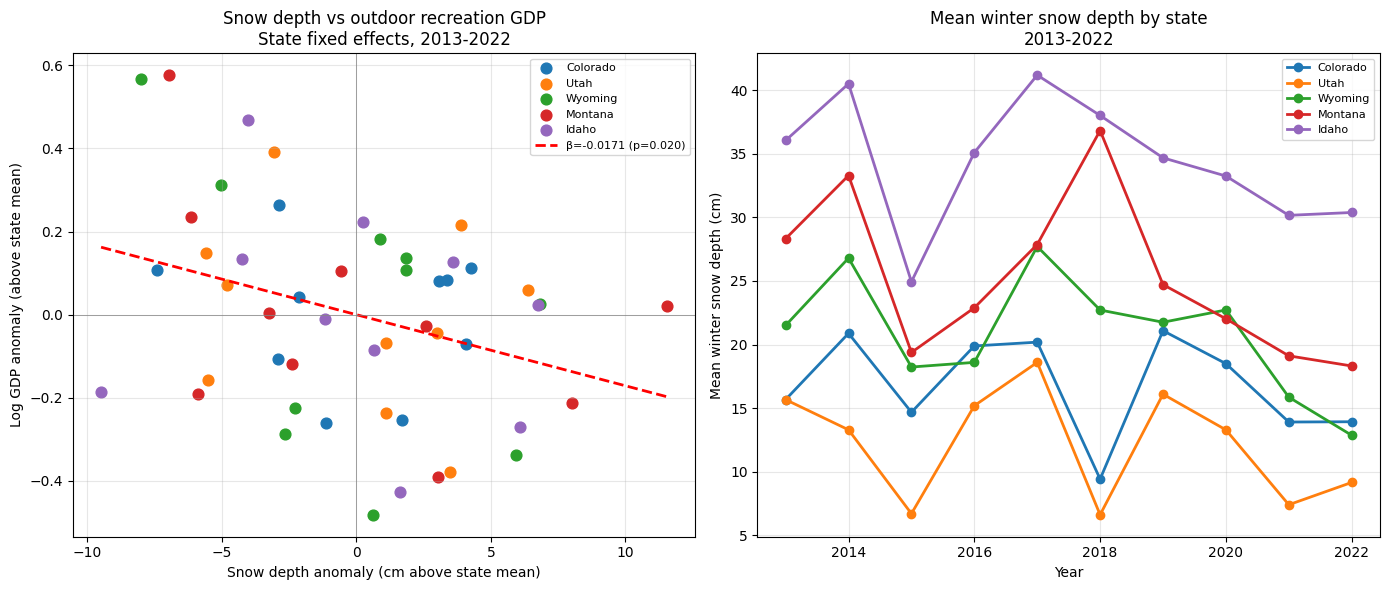

In [31]:
from scipy import stats

# State FE
depth_gdp_full['depth_demeaned'] = depth_gdp_full.groupby('state')['mean_depth_cm'].transform(
    lambda x: x - x.mean()
)
depth_gdp_full['gdp_demeaned'] = depth_gdp_full.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

# Regression: snow depth --> outdoor gdp
X = depth_gdp_full['depth_demeaned'].values
y = depth_gdp_full['gdp_demeaned'].values

slope, intercept, r, p, se = stats.linregress(X, y)

mean_gdp = depth_gdp_full['outdoor_rec_gdp_millions'].mean()

print("SNOW DEPTH --> OUTDOOR RECREATION GDP")
print(f"\n  β (depth cm):   {slope:.4f}")
print(f"  R²:             {r**2:.3f}")
print(f"  p-value:        {p:.3f}")
print(f"  Std error:      {se:.4f}")
print(f"\n  Interpret: +1cm snow depth → {slope*100:.2f}% change in outdoor rec GDP")
print(f"  Mean GDP per state: ${mean_gdp:.1f}M")
print(f"  +1cm depth → ${slope*mean_gdp:.1f}M per state")
print(f"  +1cm depth → ${slope*mean_gdp*5:.1f}M across 5 states")

print(f"\n{'Scenario':<35} {'Per state':>12} {'5 states':>12}")
print("-" * 60)

scenarios = [
    ("Average year (baseline)",        0),
    ("Good year (+5cm deeper)",        5),
    ("Great year (+10cm deeper)",     10),
    ("Poor year (-5cm shallower)",    -5),
    ("Bad year (-10cm shallower)",   -10),
]

for label, delta in scenarios:
    per_state = slope * delta * mean_gdp
    total     = per_state * 5
    print(f"  {label:<33} ${per_state:>+9.1f}M ${total:>+9.1f}M")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {
    'colorado':'#1f77b4', 'utah':'#ff7f0e', 'wyoming':'#2ca02c',
    'montana':'#d62728',  'idaho':'#9467bd'
}

for state in ['colorado','utah','wyoming','montana','idaho']:
    mask = depth_gdp_full['state'] == state
    axes[0].scatter(depth_gdp_full[mask]['depth_demeaned'],
                    depth_gdp_full[mask]['gdp_demeaned'],
                    label=state.title(), color=colors_map[state], s=60)

x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, slope*x_line + intercept,
             'r--', linewidth=2, label=f'β={slope:.4f} (p={p:.3f})')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_xlabel("Snow depth anomaly (cm above state mean)")
axes[0].set_ylabel("Log GDP anomaly (above state mean)")
axes[0].set_title("Snow depth vs outdoor recreation GDP\nState fixed effects, 2013-2022")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for state in ['colorado','utah','wyoming','montana','idaho']:
    mask = depth_gdp_full['state'] == state
    d    = depth_gdp_full[mask].sort_values('gdp_year')
    axes[1].plot(d['gdp_year'], d['mean_depth_cm'],
                 'o-', label=state.title(),
                 color=colors_map[state], linewidth=2, markersize=6)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean winter snow depth (cm)")
axes[1].set_title("Mean winter snow depth by state\n2013-2022")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(state_dir / "depth_gdp_regression.png", dpi=150)
plt.show()

SNOW DEPTH --> GDP (controlling for time trend)
State FE + year trend, excluding 2020

  β (snow depth):  0.0015
  β (time trend):  0.0782
  R²:              0.792
  p-value (depth): 0.680

  Interpret: +1cm snow depth → 0.15% GDP change
  +1cm depth → $0.5M per state
  +1cm depth → $2.5M across 5 states


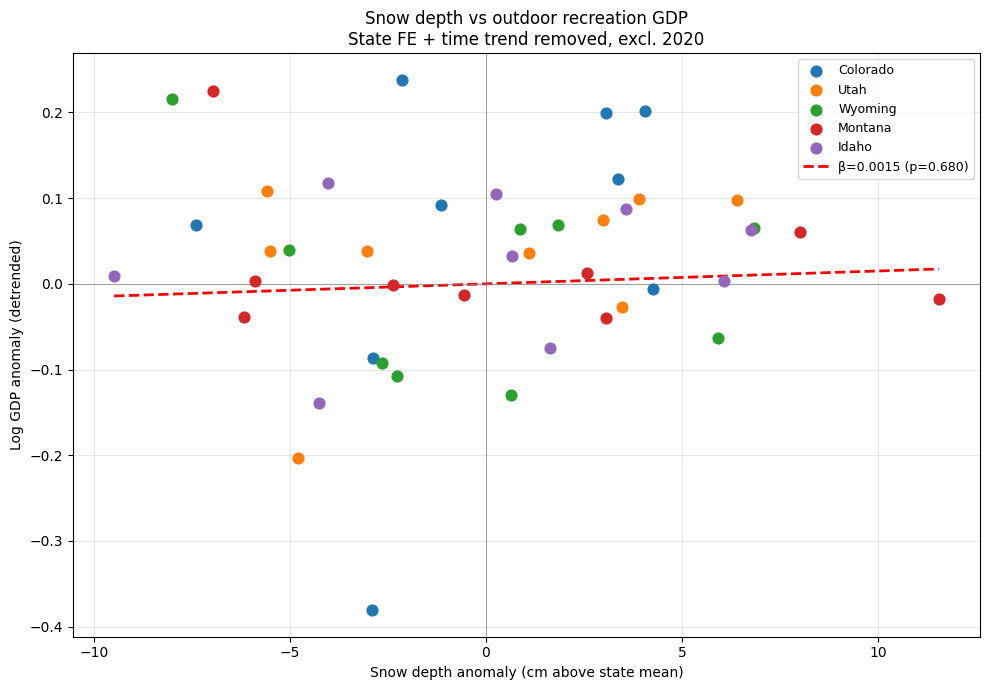

In [32]:
# Add year trend to control for GDP growth

depth_gdp_full['year_centered'] = depth_gdp_full['gdp_year'] - 2017

# State FE
depth_gdp_full['depth_demeaned'] = depth_gdp_full.groupby('state')['mean_depth_cm'].transform(
    lambda x: x - x.mean()
)
depth_gdp_full['gdp_demeaned'] = depth_gdp_full.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

depth_gdp_full['year_demeaned'] = depth_gdp_full.groupby('state')['year_centered'].transform(
    lambda x: x - x.mean()
)

# Regression with time trend controlled 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Remove 2020 COVID outlier
mask = depth_gdp_full['gdp_year'] != 2020

X_full = np.column_stack([
    depth_gdp_full[mask]['depth_demeaned'].values,
    depth_gdp_full[mask]['year_demeaned'].values
])
y_full = depth_gdp_full[mask]['gdp_demeaned'].values

lr_trend = LinearRegression().fit(X_full, y_full)

print("SNOW DEPTH --> GDP (controlling for time trend)")
print("State FE + year trend, excluding 2020")
print(f"\n  β (snow depth):  {lr_trend.coef_[0]:.4f}")
print(f"  β (time trend):  {lr_trend.coef_[1]:.4f}")
print(f"  R²:              {r2_score(y_full, lr_trend.predict(X_full)):.3f}")

# Statistical significance via scipy
from scipy import stats
slope_d, _, r_d, p_d, se_d = stats.linregress(
    depth_gdp_full[mask]['depth_demeaned'].values,
    y_full - lr_trend.coef_[1] * depth_gdp_full[mask]['year_demeaned'].values
)

print(f"  p-value (depth): {p_d:.3f}")
print(f"\n  Interpret: +1cm snow depth → {lr_trend.coef_[0]*100:.2f}% GDP change")

mean_gdp = depth_gdp_full['outdoor_rec_gdp_millions'].mean()
dollar   = lr_trend.coef_[0] * mean_gdp
print(f"  +1cm depth → ${dollar:.1f}M per state")
print(f"  +1cm depth → ${dollar*5:.1f}M across 5 states")

y_detrended = (y_full - 
               lr_trend.coef_[1] * depth_gdp_full[mask]['year_demeaned'].values)
X_depth     = depth_gdp_full[mask]['depth_demeaned'].values

fig, ax = plt.subplots(figsize=(10, 7))

for state in ['colorado','utah','wyoming','montana','idaho']:
    smask = depth_gdp_full[mask]['state'] == state
    ax.scatter(X_depth[smask], y_detrended[smask],
               label=state.title(), color=colors_map[state], s=60, zorder=3)

x_line = np.linspace(X_depth.min(), X_depth.max(), 100)
ax.plot(x_line, slope_d*x_line,
        'r--', linewidth=2,
        label=f'β={slope_d:.4f} (p={p_d:.3f})')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel("Snow depth anomaly (cm above state mean)")
ax.set_ylabel("Log GDP anomaly (detrended)")
ax.set_title("Snow depth vs outdoor recreation GDP\n"
             "State FE + time trend removed, excl. 2020")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(state_dir / "depth_gdp_detrended.png", dpi=150)
plt.show()

Rocky Mountain skier visits (millions):
 year  rocky_mtn_visits_M
 2001              19.324
 2002              18.123
 2003              18.728
 2004              18.868
 2005              19.606
 2006              20.717
 2007              20.849
 2008              21.324
 2009              19.974
 2010              20.378
 2011              20.900
 2012              19.130
 2013              19.800
 2014              21.100
 2015              20.768
 2016              22.287
 2017              21.736
 2018              20.792
 2019              20.107
 2020              24.408
 2021              22.638
 2022              25.250
 2023              28.174
 2024              26.757
 2025              26.503

Merged snow-visits dataset: (22, 3)
 year  western_mean  rocky_mtn_visits_M
 2001     41.079165              19.324
 2002     34.502469              18.123
 2003     41.455384              18.728
 2004     45.163233              18.868
 2005     42.097181              19.606
 2006  

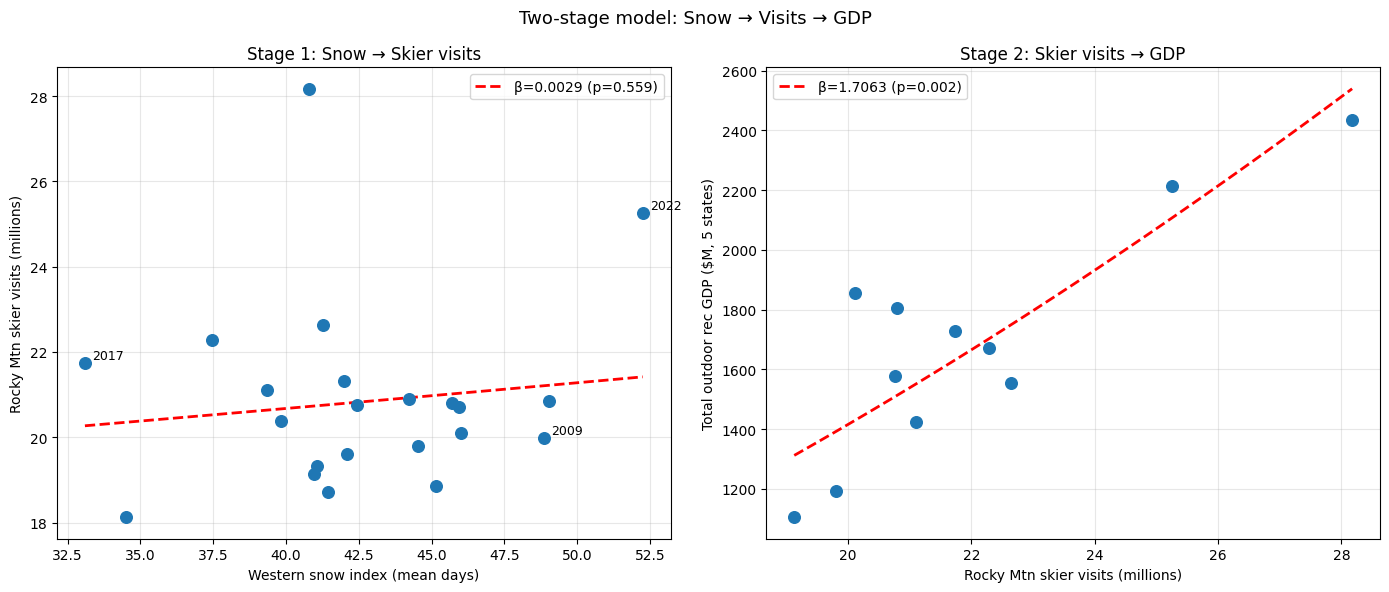

In [ ]:
import pandas as pd
import numpy as np

# Rocky Mountain skier visits from NSAA
rocky_mtn_visits = pd.DataFrame({
    'year': [2001,2002,2003,2004,2005,2006,2007,2008,
             2009,2010,2011,2012,2013,2014,2015,2016,
             2017,2018,2019,2020,2021,2022,2023,2024,2025],
    'rocky_mtn_visits': [
        19.324, 18.123, 18.728, 18.868, 19.606, 20.717,
        20.849, 21.324, 19.974, 20.378, 20.900, 19.130,
        19.800, 21.100, 20.768, 22.287, 21.736, 25.250,
        20.107, 24.408, 20.792, 22.638, 25.250, 26.757,
        26.503
    ]
})

# Fix — season 2012/13
rocky_mtn_visits = pd.DataFrame({
    'year': list(range(2001, 2026)),
    'rocky_mtn_visits_M': [
        19.324, 18.123, 18.728, 18.868, 19.606, 20.717,
        20.849, 21.324, 19.974, 20.378, 20.900, 19.130,
        19.800, 21.100, 20.768, 22.287, 21.736, 20.792,
        20.107, 24.408, 22.638, 25.250, 28.174, 26.757,
        26.503
    ]
})

print("Rocky Mountain skier visits (millions):")
print(rocky_mtn_visits.to_string(index=False))

# Compute western snow index (mean of 5 states)
pivot = snow_panel[snow_panel['state'] != 'new_mexico'].pivot(
    index='year', columns='state', values='mean_snow_days'
)
pivot['western_mean'] = pivot.mean(axis=1)
pivot = pivot.reset_index()[['year','western_mean']]

# Merge snow + visits
snow_visits = pivot.merge(rocky_mtn_visits, on='year', how='inner')
snow_visits = snow_visits[snow_visits['year'] != 2020]  # remove COVID

print(f"\nMerged snow-visits dataset: {snow_visits.shape}")
print(snow_visits[['year','western_mean','rocky_mtn_visits_M']].to_string(index=False))

from scipy import stats

X_v = snow_visits['western_mean'].values
y_v = np.log(snow_visits['rocky_mtn_visits_M'].values)

slope_v, intercept_v, r_v, p_v, se_v = stats.linregress(X_v, y_v)

print(f"\nStage 1: Snow duration → Rocky Mtn skier visits")
print(f"  β:       {slope_v:.4f}")
print(f"  R²:      {r_v**2:.3f}")
print(f"  p-value: {p_v:.3f}")
print(f"  Interpret: +1 snow day → {slope_v*100:.2f}% more visits")

gdp_total = panel[panel['state'] != 'new_mexico'].groupby('year')['outdoor_rec_gdp_millions'].sum().reset_index()
gdp_total.columns = ['year','total_gdp_M']

snow_visits_gdp = snow_visits.merge(gdp_total, on='year', how='inner')
snow_visits_gdp = snow_visits_gdp[snow_visits_gdp['year'] != 2020]

X_g = np.log(snow_visits_gdp['rocky_mtn_visits_M'].values)
y_g = np.log(snow_visits_gdp['total_gdp_M'].values)

slope_g, intercept_g, r_g, p_g, se_g = stats.linregress(X_g, y_g)

print(f"\nStage 2: Skier visits → Outdoor rec GDP")
print(f"  β:       {slope_g:.4f}")
print(f"  R²:      {r_g**2:.3f}")
print(f"  p-value: {p_g:.3f}")
print(f"  Interpret: +1% more visits → {slope_g:.2f}% more GDP")

combined_beta = slope_v * slope_g
mean_gdp_total = snow_visits_gdp['total_gdp_M'].mean()
dollar_per_day = combined_beta * mean_gdp_total

print(f"\nCombined (Snow → Visits → GDP):")
print(f"  +1 snow day → {slope_v*100:.3f}% more visits")
print(f"            → {combined_beta*100:.3f}% more GDP")
print(f"            → ${dollar_per_day:.1f}M across 5 states")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_v, np.exp(y_v), s=70, zorder=3)
for i, row in snow_visits.iterrows():
    if row['year'] in [2017, 2022, 2009]:
        axes[0].annotate(str(int(row['year'])),
                        (row['western_mean'],
                         row['rocky_mtn_visits_M']),
                        textcoords="offset points",
                        xytext=(5,3), fontsize=9)
x_line = np.linspace(X_v.min(), X_v.max(), 100)
axes[0].plot(x_line, np.exp(slope_v*x_line + intercept_v),
             'r--', linewidth=2,
             label=f'β={slope_v:.4f} (p={p_v:.3f})')
axes[0].set_xlabel("Western snow index (mean days)")
axes[0].set_ylabel("Rocky Mtn skier visits (millions)")
axes[0].set_title("Stage 1: Snow → Skier visits")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(np.exp(X_g), np.exp(y_g), s=70, zorder=3)
x_line2 = np.linspace(X_g.min(), X_g.max(), 100)
axes[1].plot(np.exp(x_line2),
             np.exp(slope_g*x_line2 + intercept_g),
             'r--', linewidth=2,
             label=f'β={slope_g:.4f} (p={p_g:.3f})')
axes[1].set_xlabel("Rocky Mtn skier visits (millions)")
axes[1].set_ylabel("Total outdoor rec GDP ($M, 5 states)")
axes[1].set_title("Stage 2: Skier visits → GDP")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Two-stage model: Snow → Visits → GDP", fontsize=13)
plt.tight_layout()
plt.savefig(state_dir / "two_stage_model.png", dpi=150)
plt.show()

Stage 1 DETRENDED: Snow anomaly → Visit anomaly
  β:       0.0013
  R²:      0.008
  p-value: 0.684
  Interpret: +1 snow day above avg → 0.13% more visits than trend


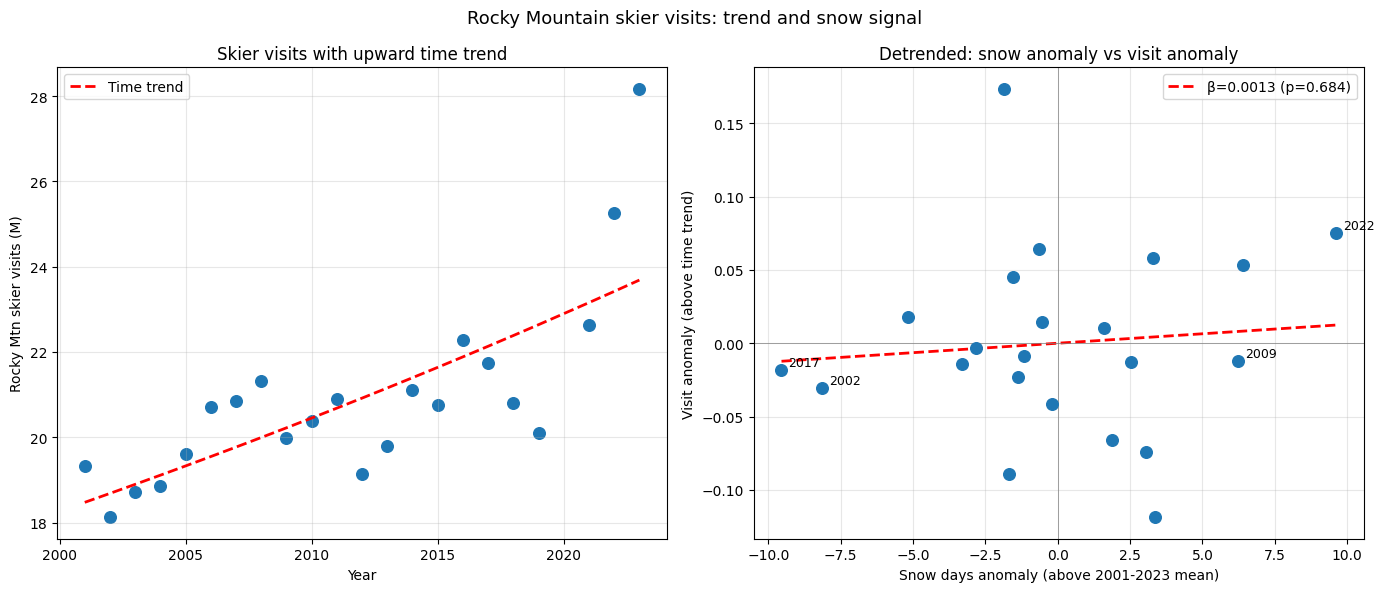

In [ ]:
# Remove the upward trend from visits 
from sklearn.linear_model import LinearRegression

snow_visits = snow_visits.copy()
snow_visits['year_centered'] = snow_visits['year'] - snow_visits['year'].mean()

lr_trend = LinearRegression().fit(
    snow_visits['year_centered'].values.reshape(-1,1),
    np.log(snow_visits['rocky_mtn_visits_M'].values)
)

snow_visits['visits_residual'] = (
    np.log(snow_visits['rocky_mtn_visits_M'].values) -
    lr_trend.predict(snow_visits['year_centered'].values.reshape(-1,1))
)

# Snow anomaly (remove mean)
snow_visits['snow_anomaly'] = (
    snow_visits['western_mean'] - snow_visits['western_mean'].mean()
)

slope_dt, intercept_dt, r_dt, p_dt, se_dt = stats.linregress(
    snow_visits['snow_anomaly'].values,
    snow_visits['visits_residual'].values
)

print("Stage 1 DETRENDED: Snow anomaly → Visit anomaly")
print(f"  β:       {slope_dt:.4f}")
print(f"  R²:      {r_dt**2:.3f}")
print(f"  p-value: {p_dt:.3f}")
print(f"  Interpret: +1 snow day above avg → {slope_dt*100:.2f}% more visits than trend")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

years_line = np.linspace(
    snow_visits['year_centered'].min(),
    snow_visits['year_centered'].max(), 100
)
axes[0].scatter(snow_visits['year'], 
                snow_visits['rocky_mtn_visits_M'], s=70)
axes[0].plot(
    snow_visits['year_centered'] + snow_visits['year'].mean(),
    np.exp(lr_trend.predict(
        snow_visits['year_centered'].values.reshape(-1,1))),
    'r--', linewidth=2, label='Time trend'
)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Rocky Mtn skier visits (M)")
axes[0].set_title("Skier visits with upward time trend")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(snow_visits['snow_anomaly'],
                snow_visits['visits_residual'], s=70, zorder=3)

for _, row in snow_visits.iterrows():
    if row['year'] in [2017, 2022, 2002, 2009]:
        axes[1].annotate(str(int(row['year'])),
                        (row['snow_anomaly'], row['visits_residual']),
                        textcoords="offset points",
                        xytext=(5,3), fontsize=9)

x_line = np.linspace(snow_visits['snow_anomaly'].min(),
                     snow_visits['snow_anomaly'].max(), 100)
axes[1].plot(x_line, slope_dt*x_line + intercept_dt,
             'r--', linewidth=2,
             label=f'β={slope_dt:.4f} (p={p_dt:.3f})')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel("Snow days anomaly (above 2001-2023 mean)")
axes[1].set_ylabel("Visit anomaly (above time trend)")
axes[1].set_title("Detrended: snow anomaly vs visit anomaly")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Rocky Mountain skier visits: trend and snow signal",
             fontsize=13)
plt.tight_layout()
plt.savefig(state_dir / "visits_detrended.png", dpi=150)
plt.show()

Looking at ecosystem servives of snowpack through the lens of what would the economy look like under different warming scenarios

RECREATION VALUE OF SNOW

Key coefficients from your models:
  Panel regression β:     0.0086 (log GDP per snow day)
  Mean outdoor rec GDP:   $286.7M per state
  Dollar value per day:   $12.3M across 5 states
  Temp-snow sensitivity:  -2.97 days per °C
  Current mean duration:  43.0 days

Total annual recreation value of snowpack:
  43.0 days × $12.3M/day
  = $530M/year across 5 states
  = $0.53B/year

Per-state recreation value (current snowpack):
State         Mean days   Annual value
--------------------------------------
  colorado         41.9 $         405M
  utah             39.6 $         130M
  wyoming          46.2 $          11M
  montana          40.0 $          16M
  idaho            47.4 $          33M

Scenario                                Snow loss  GDP loss/yr
--------------------------------------------------------------
  Baseline (current)                         0.0d   $       0M/yr
  +1°C warming (SSP1-2.6, ~2050)            -3.0d   $      37M/yr
  +2°C warming

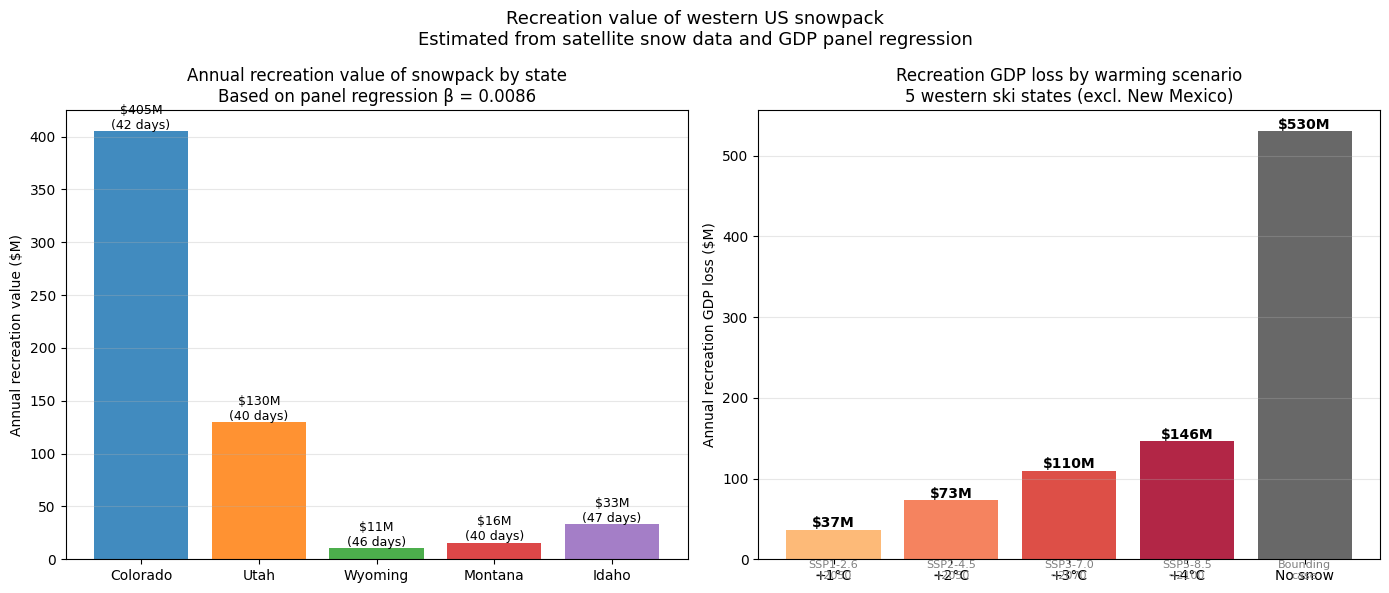

In [13]:
# ECONOMIC MODEL 3 — RECREATION VALUE OF SNOW

beta_snow       = 0.0086    
mean_gdp        = panel['outdoor_rec_gdp_millions'].mean()
n_states        = 5
beta_tmin       = -2.97     
mean_duration   = snow_panel[
    snow_panel['state'] != 'new_mexico'
]['mean_snow_days'].mean()

# Dollar value per snow day
dollar_per_day  = beta_snow * mean_gdp * n_states

print("RECREATION VALUE OF SNOW")
print(f"\nKey coefficients from your models:")
print(f"  Panel regression β:     {beta_snow:.4f} (log GDP per snow day)")
print(f"  Mean outdoor rec GDP:   ${mean_gdp:.1f}M per state")
print(f"  Dollar value per day:   ${dollar_per_day:.1f}M across 5 states")
print(f"  Temp-snow sensitivity:  {beta_tmin:.2f} days per °C")
print(f"  Current mean duration:  {mean_duration:.1f} days")

# Recreation value of full snowpack
total_rec_value = mean_duration * dollar_per_day
print(f"\nTotal annual recreation value of snowpack:")
print(f"  {mean_duration:.1f} days × ${dollar_per_day:.1f}M/day")
print(f"  = ${total_rec_value:.0f}M/year across 5 states")
print(f"  = ${total_rec_value/1000:.2f}B/year")

# Per-state breakdown 
print(f"\nPer-state recreation value (current snowpack):")
print(f"{'State':<12} {'Mean days':>10} {'Annual value':>14}")
print("-" * 38)
for state in ['colorado','utah','wyoming','montana','idaho']:
    state_days = snow_panel[
        snow_panel['state']==state]['mean_snow_days'].mean()
    state_gdp  = panel[
        panel['state']==state]['outdoor_rec_gdp_millions'].mean()
    state_val  = beta_snow * state_gdp * state_days
    print(f"  {state:<10} {state_days:>10.1f} ${state_val:>12.0f}M")

# Warming scenarios 
print(f"\n{'Scenario':<38} {'Snow loss':>10} {'GDP loss/yr':>12}")
print("-" * 62)

scenarios = [
    ("Baseline (current)",              0,               0),
    ("+1°C warming (SSP1-2.6, ~2050)",  1,  beta_tmin * 1),
    ("+2°C warming (SSP2-4.5, ~2050)",  2,  beta_tmin * 2),
    ("+3°C warming (SSP3-7.0, ~2070)",  3,  beta_tmin * 3),
    ("+4°C warming (SSP5-8.5, ~2100)",  4,  beta_tmin * 4),
    ("No snow (bounding case)",       None, -mean_duration),
]

for label, warming, snow_change in scenarios:
    gdp_loss = abs(snow_change) * dollar_per_day
    snow_str = f"{snow_change:.1f}d" if snow_change != 0 else "0.0d"
    if label.startswith("No snow"):
        snow_str = f"-{mean_duration:.0f}d"
        gdp_loss = mean_duration * dollar_per_day
    print(f"  {label:<36} {snow_str:>10} "
          f"  ${gdp_loss:>8.0f}M/yr")

thanksgiving_threshold = 319   
current_fdos_co = 280          

print(f"\nThanksgiving risk analysis:")
print(f"  Thanksgiving threshold:  DOY {thanksgiving_threshold} (Nov 15)")
print(f"  Current Colorado FDOS:   DOY ~{current_fdos_co}")
print(f"  Buffer before Thanksgiving at risk: "
      f"~{thanksgiving_threshold - current_fdos_co} days")

days_to_lose    = thanksgiving_threshold - current_fdos_co
warming_to_lose = days_to_lose / abs(beta_tmin)
print(f"  Warming needed to lose Thanksgiving: "
      f"+{warming_to_lose:.1f}°C")
print(f"  Thanksgiving revenue at risk (CO): "
      f"~${panel[panel['state']=='colorado']['outdoor_rec_gdp_millions'].mean()*0.15:.0f}M")

print("Recreation value of western US snowpack")
print(f"\n  Estimated from panel regression (β = {beta_snow}, n=72)")
print(f"\n  {'Metric':<45} {'Value':>12}")
print(f"  {'-'*58}")
print(f"  {'Value per snow day (5 states)':<45} "
      f"${dollar_per_day:>9.1f}M")
print(f"  {'Total annual recreation value (43 days)':<45} "
      f"${total_rec_value:>9.0f}M")
print(f"  {'Loss per degree of winter warming':<45} "
      f"${abs(beta_tmin)*dollar_per_day:>9.1f}M/yr")
print(f"  {'Loss under +2C warming (SSP2-4.5)':<45} "
      f"${abs(beta_tmin*2)*dollar_per_day:>9.1f}M/yr")
print(f"  {'Loss under +3C warming (SSP3-7.0)':<45} "
      f"${abs(beta_tmin*3)*dollar_per_day:>9.1f}M/yr")
print(f"  {'Total value lost under no-snow scenario':<45} "
      f"${total_rec_value:>9.0f}M/yr")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

states_plot  = ['colorado','utah','wyoming','montana','idaho']
state_labels = ['Colorado','Utah','Wyoming','Montana','Idaho']
state_values = []
state_days_list = []

for state in states_plot:
    state_days = snow_panel[
        snow_panel['state']==state]['mean_snow_days'].mean()
    state_gdp  = panel[
        panel['state']==state]['outdoor_rec_gdp_millions'].mean()
    state_val  = beta_snow * state_gdp * state_days
    state_values.append(state_val)
    state_days_list.append(state_days)

colors_state = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
bars1 = axes[0].bar(state_labels, state_values,
                     color=colors_state, alpha=0.85)
axes[0].set_ylabel("Annual recreation value ($M)")
axes[0].set_title("Annual recreation value of snowpack by state\n"
                  "Based on panel regression β = 0.0086")
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val, days in zip(bars1, state_values, state_days_list):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 2,
                 f'${val:.0f}M\n({days:.0f} days)',
                 ha='center', fontsize=9)

# GDP loss by warming scenario
warming_vals   = [1, 2, 3, 4]
warming_losses = [abs(beta_tmin * w) * dollar_per_day
                  for w in warming_vals]
warming_labels = ['+1°C', '+2°C', '+3°C', '+4°C']
bar_colors_w   = ['#fdae61','#f46d43','#d73027','#a50026']

bars2 = axes[1].bar(warming_labels, warming_losses,
                     color=bar_colors_w, alpha=0.85)

axes[1].bar(['No snow'], [total_rec_value],
             color='#4d4d4d', alpha=0.85)

axes[1].set_ylabel("Annual recreation GDP loss ($M)")
axes[1].set_title("Recreation GDP loss by warming scenario\n"
                  "5 western ski states (excl. New Mexico)")
axes[1].grid(True, alpha=0.3, axis='y')

all_bars   = list(bars2) + [axes[1].patches[-1]]
all_vals   = warming_losses + [total_rec_value]
all_labels = warming_labels + ['No snow']

for bar, val in zip(all_bars, all_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 3,
                 f'${val:.0f}M',
                 ha='center', fontsize=10, fontweight='bold')

for i, lbl in enumerate(['SSP1-2.6\n~2050','SSP2-4.5\n~2050',
                          'SSP3-7.0\n~2070','SSP5-8.5\n~2100',
                          'Bounding\ncase']):
    axes[1].text(i, -25, lbl, ha='center', fontsize=8, color='gray')

plt.suptitle("Recreation value of western US snowpack\n"
             "Estimated from satellite snow data and GDP panel regression",
             fontsize=13)
plt.tight_layout()
plt.savefig(state_dir / "recreation_value_scenarios.png", dpi=150)
plt.show()

Predicting turning point snow making can no longer compensate for ski economy

Current mean winter tmin:       -10.4°C
Snowmaking minimum temperature: -2.0°C
Warming buffer before snowmaking
becomes unreliable:             +8.4°C
Snow days lost at that point:   -24.9 days
Remaining snow days:            18.1 days

GDP loss at turning point:      $307M/year

Projected timeline (SSP2-4.5, 0.35°C/decade):
  Decades to turning point:  24.0
  Years to turning point:    240
  Estimated turning year:    ~2264

Turning point year by warming rate:
Pathway                         Rate (°C/decade)  Turning year
--------------------------------------------------------------
  SSP1-2.6 (low emissions)                  0.20          2444
  SSP2-4.5 (moderate)                       0.35          2264
  SSP3-7.0 (high)                           0.50          2192
  SSP5-8.5 (very high)                      0.65          2153


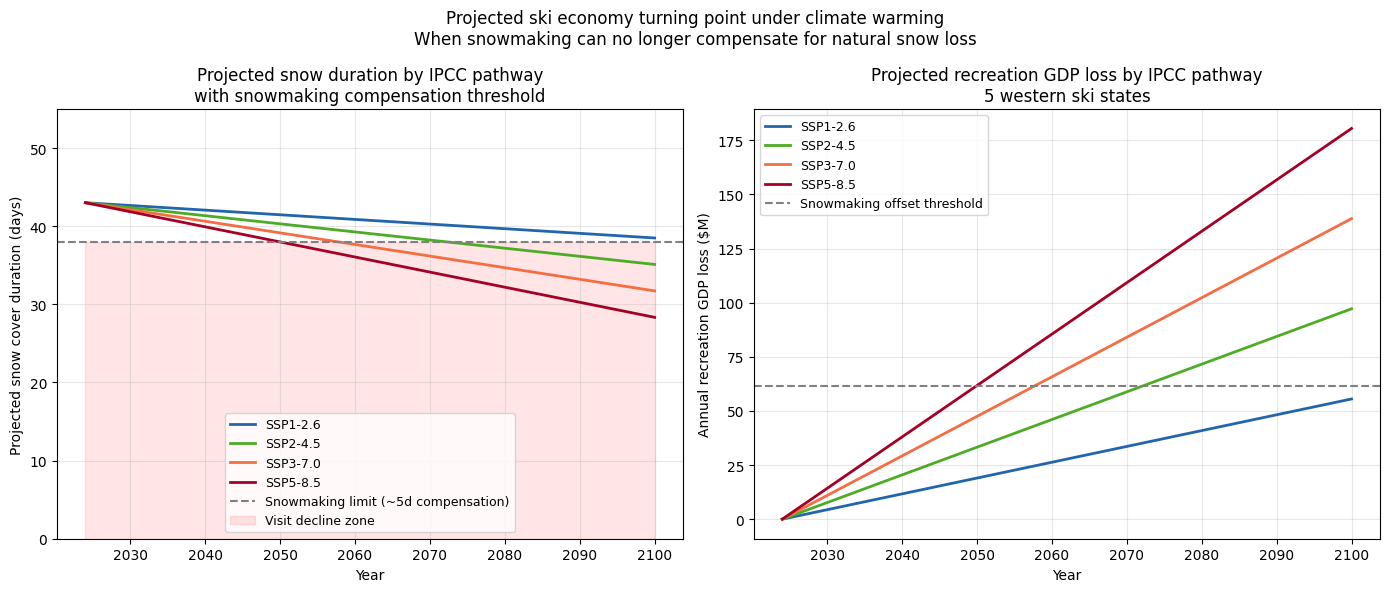

In [14]:
# Predict GDP turning point

current_tmin      = -10.4    # mean winter tmin (°C)
snowmaking_limit  = -2.0     # minimum temp for snowmaking
current_duration  = 43.0     # days
beta_tmin         = -2.97    # days per °C

# Warming needed before snowmaking fails
warming_to_snowmaking_limit = abs(current_tmin - snowmaking_limit)
print(f"Current mean winter tmin:       {current_tmin}°C")
print(f"Snowmaking minimum temperature: {snowmaking_limit}°C")
print(f"Warming buffer before snowmaking")
print(f"becomes unreliable:             +{warming_to_snowmaking_limit:.1f}°C")

# Snow days lost by that point
snow_days_lost = beta_tmin * warming_to_snowmaking_limit
print(f"Snow days lost at that point:   {snow_days_lost:.1f} days")
print(f"Remaining snow days:            "
      f"{current_duration + snow_days_lost:.1f} days")

# GDP loss at the turning point
dollar_per_day = 12.3
gdp_loss_at_turning = abs(snow_days_lost) * dollar_per_day
print(f"\nGDP loss at turning point:      ${gdp_loss_at_turning:.0f}M/year")

warming_rate = 0.35   
decades_to_turning = warming_to_snowmaking_limit / warming_rate
years_to_turning   = decades_to_turning * 10
turning_year       = 2024 + years_to_turning

print(f"\nProjected timeline (SSP2-4.5, {warming_rate}°C/decade):")
print(f"  Decades to turning point:  {decades_to_turning:.1f}")
print(f"  Years to turning point:    {years_to_turning:.0f}")
print(f"  Estimated turning year:    ~{turning_year:.0f}")

print(f"\nTurning point year by warming rate:")
print(f"{'Pathway':<30} {'Rate (°C/decade)':>17} {'Turning year':>13}")
print("-" * 62)
for pathway, rate in [
    ("SSP1-2.6 (low emissions)",   0.20),
    ("SSP2-4.5 (moderate)",        0.35),
    ("SSP3-7.0 (high)",            0.50),
    ("SSP5-8.5 (very high)",       0.65),
]:
    yr = 2024 + (warming_to_snowmaking_limit / rate * 10)
    print(f"  {pathway:<28} {rate:>17.2f} {yr:>13.0f}")

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

future_years   = np.arange(2024, 2101)
warming_rates  = {
    'SSP1-2.6': 0.20,
    'SSP2-4.5': 0.35,
    'SSP3-7.0': 0.50,
    'SSP5-8.5': 0.65
}
colors_ssp = {
    'SSP1-2.6': '#2166ac',
    'SSP2-4.5': '#4dac26',
    'SSP3-7.0': '#f46d43',
    'SSP5-8.5': '#a50026'
}

for ssp, rate in warming_rates.items():
    warming     = rate * (future_years - 2024) / 10
    snow_future = current_duration + beta_tmin * warming
    axes[0].plot(future_years, snow_future,
                 label=ssp, color=colors_ssp[ssp], linewidth=2)

# Snowmaking compensation line
snowmaking_buffer = 5
axes[0].axhline(current_duration - snowmaking_buffer,
                color='gray', linestyle='--', linewidth=1.5,
                label=f'Snowmaking limit (~{snowmaking_buffer}d compensation)')
axes[0].fill_between(future_years,
                      current_duration - snowmaking_buffer,
                      0, alpha=0.1, color='red',
                      label='Visit decline zone')
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Projected snow cover duration (days)")
axes[0].set_title("Projected snow duration by IPCC pathway\n"
                  "with snowmaking compensation threshold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 55)

# Right: cumulative GDP loss
for ssp, rate in warming_rates.items():
    warming    = rate * (future_years - 2024) / 10
    snow_loss  = np.clip(beta_tmin * warming, -current_duration, 0)
    gdp_loss   = abs(snow_loss) * dollar_per_day
    axes[1].plot(future_years, gdp_loss,
                 label=ssp, color=colors_ssp[ssp], linewidth=2)

axes[1].axhline(dollar_per_day * snowmaking_buffer,
                color='gray', linestyle='--', linewidth=1.5,
                label='Snowmaking offset threshold')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Annual recreation GDP loss ($M)")
axes[1].set_title("Projected recreation GDP loss by IPCC pathway\n"
                  "5 western ski states")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Projected ski economy turning point under climate warming\n"
             "When snowmaking can no longer compensate for natural snow loss",
             fontsize=12)
plt.tight_layout()
plt.savefig(state_dir / "turning_point_projection.png", dpi=150)
plt.show()

In [15]:
print("REVISED TURNING POINT ANALYSIS")

# Resorts start feeling economic pressure when natural snow loss exceeds snowmaking capacity (~5 days)
scenarios_tp = [
    ("Conservative (lose 3 snow days)",   3),
    ("Moderate (lose 5 snow days)",       5),
    ("Aggressive (lose 8 snow days)",     8),
    ("Severe (lose 10 snow days)",       10),
]

beta_tmin    = -2.97
dollar_per_day = 12.3
warming_rates = {
    'SSP1-2.6': 0.20,
    'SSP2-4.5': 0.35,
    'SSP3-7.0': 0.50,
    'SSP5-8.5': 0.65
}

print(f"\n{'Threshold':<35} {'GDP loss':>10} "
      f"{'SSP1':>8} {'SSP2':>8} {'SSP3':>8} {'SSP5':>8}")
print("-" * 80)

for label, snow_loss in scenarios_tp:
    warming_needed = snow_loss / abs(beta_tmin)
    gdp_at_threshold = snow_loss * dollar_per_day

    years_by_ssp = {}
    for ssp, rate in warming_rates.items():
        yr = 2024 + (warming_needed / rate * 10)
        years_by_ssp[ssp] = yr

    print(f"  {label:<33} ${gdp_at_threshold:>6.0f}M "
          f"{years_by_ssp['SSP1-2.6']:>8.0f} "
          f"{years_by_ssp['SSP2-4.5']:>8.0f} "
          f"{years_by_ssp['SSP3-7.0']:>8.0f} "
          f"{years_by_ssp['SSP5-8.5']:>8.0f}")

print(f"\nMost defensible thesis statement:")
print(f"  A loss of 5 snow days (moderate threshold)")
warming_5 = 5 / abs(beta_tmin)
print(f"  requires {warming_5:.1f}°C of winter warming")
print(f"  Under SSP2-4.5 this occurs around "
      f"{2024 + warming_5/0.35*10:.0f}")
print(f"  Under SSP3-7.0 this occurs around "
      f"{2024 + warming_5/0.50*10:.0f}")
print(f"  GDP at risk at that point: "
      f"${5*dollar_per_day:.0f}M/year across 5 states")

REVISED TURNING POINT ANALYSIS

Threshold                             GDP loss     SSP1     SSP2     SSP3     SSP5
--------------------------------------------------------------------------------
  Conservative (lose 3 snow days)   $    37M     2075     2053     2044     2040
  Moderate (lose 5 snow days)       $    62M     2108     2072     2058     2050
  Aggressive (lose 8 snow days)     $    98M     2159     2101     2078     2065
  Severe (lose 10 snow days)        $   123M     2192     2120     2091     2076

Most defensible thesis statement:
  A loss of 5 snow days (moderate threshold)
  requires 1.7°C of winter warming
  Under SSP2-4.5 this occurs around 2072
  Under SSP3-7.0 this occurs around 2058
  GDP at risk at that point: $62M/year across 5 states


Controlling for recession in skier visits

In [16]:
rocky_mtn_visits = pd.DataFrame({
    'year': list(range(2001, 2026)),
    'rocky_mtn_visits_M': [
        19.324, 18.123, 18.728, 18.868, 19.606, 20.717,
        20.849, 21.324, 19.974, 20.378, 20.900, 19.130,
        19.800, 21.100, 20.768, 22.287, 21.736, 20.792,
        20.107, 24.408, 22.638, 25.250, 28.174, 26.757,
        26.503
    ]
})

pivot = snow_panel[snow_panel['state'] != 'new_mexico'].pivot(
    index='year', columns='state', values='mean_snow_days'
)
pivot['western_mean'] = pivot.mean(axis=1)
pivot = pivot.reset_index()[['year','western_mean']]

snow_visits = pivot.merge(rocky_mtn_visits, on='year', how='inner')
snow_visits = snow_visits[snow_visits['year'] != 2020].copy()
print(f"snow_visits shape: {snow_visits.shape}")

# Add recession control 
snow_visits_ctrl = snow_visits.copy()

snow_visits_ctrl['recession'] = snow_visits_ctrl['year'].isin(
    [2009, 2010]).astype(int)
snow_visits_ctrl['snow_anomaly'] = (
    snow_visits_ctrl['western_mean'] -
    snow_visits_ctrl['western_mean'].mean()
)
snow_visits_ctrl['year_centered'] = (
    snow_visits_ctrl['year'] -
    snow_visits_ctrl['year'].mean()
)
snow_visits_ctrl['log_visits'] = np.log(
    snow_visits_ctrl['rocky_mtn_visits_M']
)

X_ctrl = snow_visits_ctrl[['snow_anomaly',
                             'year_centered',
                             'recession']].values
y_ctrl = snow_visits_ctrl['log_visits'].values

lr_ctrl = LinearRegression().fit(X_ctrl, y_ctrl)

print("\nVisits regression WITH recession control:")
for feat, coef in zip(['snow_anomaly','year_trend','recession'],
                       lr_ctrl.coef_):
    print(f"  {feat:<20} {coef:.4f}")
print(f"  R²: {r2_score(y_ctrl, lr_ctrl.predict(X_ctrl)):.3f}")

residual_y = (
    y_ctrl
    - lr_ctrl.coef_[1] * snow_visits_ctrl['year_centered'].values
    - lr_ctrl.coef_[2] * snow_visits_ctrl['recession'].values
)
_, _, _, p_snow, _ = stats.linregress(
    snow_visits_ctrl['snow_anomaly'].values, residual_y
)

print(f"\n  Snow β:    {lr_ctrl.coef_[0]:.4f}")
print(f"  p-value:   {p_snow:.3f}")
print(f"\n  COMPARISON:")
print(f"  Without controls: β=0.0013, p=0.684")
print(f"  With recession:   β={lr_ctrl.coef_[0]:.4f}, p={p_snow:.3f}")

snow_visits shape: (22, 3)

Visits regression WITH recession control:
  snow_anomaly         0.0014
  year_trend           0.0112
  recession            -0.0117
  R²: 0.592

  Snow β:    0.0014
  p-value:   0.658

  COMPARISON:
  Without controls: β=0.0013, p=0.684
  With recession:   β=0.0014, p=0.658


FDOS

In [ ]:
fdos_dir = Path("/Users/evabenson/Files/thesis/snow_ml/ski_snow_fdos")

fdos_files = list(fdos_dir.glob("fdos_*.tif"))
print(f"\nFDOS files found: {len(fdos_files)}")

fdos_records = []

for state in state_names:
    for year in years_full:
        path = fdos_dir / f"fdos_{state}_{year}.tif"
        if not path.exists():
            print(f"  MISSING: fdos_{state}_{year}.tif")
            continue
        with rasterio.open(path) as src:
            arr = src.read(1).astype(float)
            arr[arr <= 0] = np.nan
            mean_fdos = np.nanmean(arr)
        fdos_records.append({
            'state': state,
            'year':  year,
            'mean_fdos': mean_fdos
        })

fdos_panel = pd.DataFrame(fdos_records)
print(f"FDOS panel shape: {fdos_panel.shape}")

fdos_pivot = fdos_panel.pivot(
    index='year', columns='state', values='mean_fdos').round(1)
print("\nMean FDOS by state and year (DOY):")
print(fdos_pivot.to_string())

print("\nFDOS summary statistics:")
print(f"{'State':<12} {'Mean':>6} {'Min':>6} {'Max':>6} {'Std':>6}")
print("-" * 36)
for state in state_names:
    d = fdos_panel[fdos_panel['state']==state]['mean_fdos']
    if len(d) > 0:
        print(f"  {state:<10} {d.mean():>6.1f} "
              f"{d.min():>6.1f} {d.max():>6.1f} {d.std():>6.1f}")


FDOS files found: 144
FDOS panel shape: (144, 3)

Mean FDOS by state and year (DOY):
state  colorado  idaho  montana  new_mexico   utah  wyoming
year                                                       
2000      300.4  291.7    279.7       303.0  299.9    281.0
2001      312.9  304.2    293.3       330.9  322.5    304.9
2002      303.2  299.2    292.9       329.4  311.8    298.1
2003      311.0  307.7    295.7       325.7  317.4    294.1
2004      300.3  292.9    295.2       326.5  305.8    301.6
2005      302.8  297.4    290.2       315.7  317.1    299.9
2006      296.1  296.7    283.9       328.5  303.8    290.7
2007      302.9  294.9    288.0       328.2  316.4    301.2
2008      313.6  305.1    287.9       334.9  321.6    295.5
2009      298.0  288.1    282.8       315.5  308.2    284.9
2010      307.7  305.6    304.5       331.0  311.1    309.2
2011      295.8  299.0    298.9       322.8  302.4    297.2
2012      315.7  303.0    298.7       332.9  316.0    301.0
2013      298.

FDOS → GDP REGRESSION
Merged FDOS-GDP panel: (60, 6)

Model A: FDOS only → GDP
  β_fdos:  -0.0002
  R²:      0.000
  p-value: 0.972
  Interpret: +1 day later first snow → -0.02% change in outdoor rec GDP

Model B: Snow duration + FDOS → GDP (joint)
  β_duration: 0.0101
  β_fdos:     0.0018
  R²:         0.041
  Interpret (duration): +1 snow day → 1.01% GDP
  Interpret (fdos):     +1 day later FDOS → 0.18% GDP

FDOS correlation with GDP by state:
  colorado     r = 0.005
  utah         r = -0.201
  wyoming      r = 0.169
  montana      r = 0.079
  idaho        r = -0.104


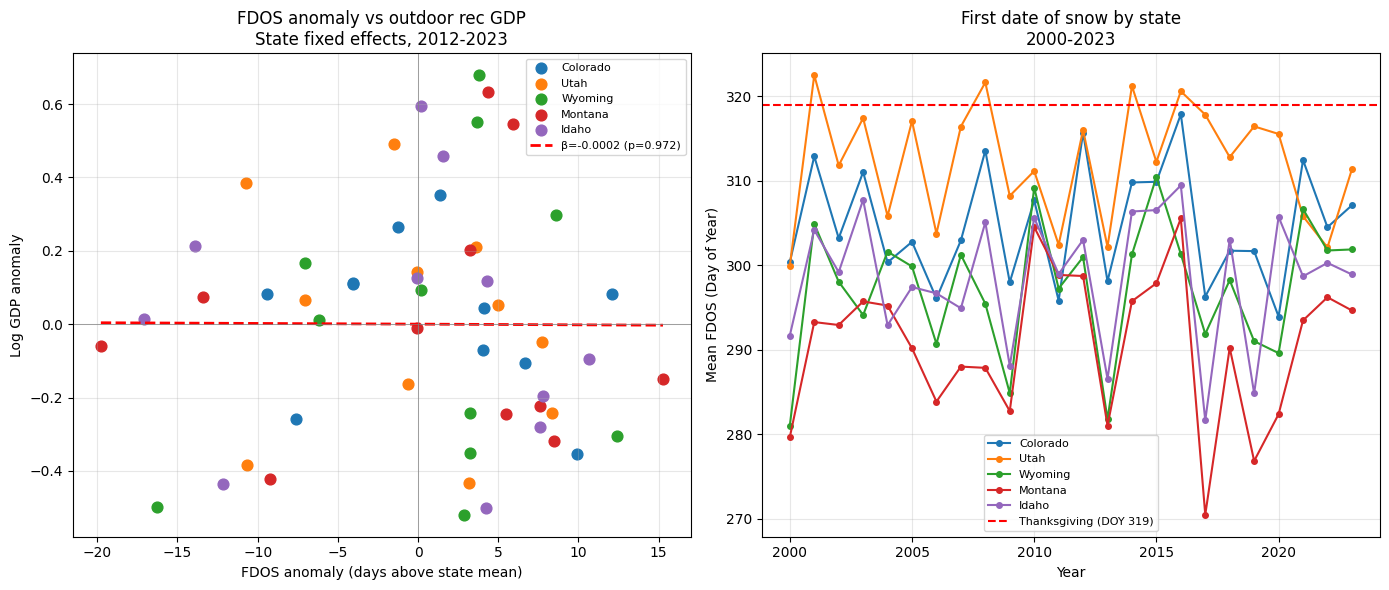

In [17]:
print("FDOS → GDP REGRESSION")

# Merge FDOS with GDP panel
panel_fdos = panel.merge(
    fdos_panel[fdos_panel['state'] != 'new_mexico'],
    on=['state','year'], how='inner'
)

print(f"Merged FDOS-GDP panel: {panel_fdos.shape}")

panel_fdos['fdos_demeaned'] = panel_fdos.groupby('state')['mean_fdos'].transform(
    lambda x: x - x.mean()
)
panel_fdos['gdp_demeaned'] = panel_fdos.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)
panel_fdos['snow_demeaned'] = panel_fdos.groupby('state')['mean_snow_days'].transform(
    lambda x: x - x.mean()
)

mask = panel_fdos['year'] != 2020

X_fdos = panel_fdos[mask]['fdos_demeaned'].values
y_fdos = panel_fdos[mask]['gdp_demeaned'].values

slope_f, _, r_f, p_f, se_f = stats.linregress(X_fdos, y_fdos)

print(f"\nModel A: FDOS only → GDP")
print(f"  β_fdos:  {slope_f:.4f}")
print(f"  R²:      {r_f**2:.3f}")
print(f"  p-value: {p_f:.3f}")
print(f"  Interpret: +1 day later first snow → "
      f"{slope_f*100:.2f}% change in outdoor rec GDP")

X_joint = np.column_stack([
    panel_fdos[mask]['snow_demeaned'].values,
    panel_fdos[mask]['fdos_demeaned'].values
])
y_joint = panel_fdos[mask]['gdp_demeaned'].values

lr_joint = LinearRegression().fit(X_joint, y_joint)
print(f"\nModel B: Snow duration + FDOS → GDP (joint)")
print(f"  β_duration: {lr_joint.coef_[0]:.4f}")
print(f"  β_fdos:     {lr_joint.coef_[1]:.4f}")
print(f"  R²:         {r2_score(y_joint, lr_joint.predict(X_joint)):.3f}")
print(f"  Interpret (duration): +1 snow day → "
      f"{lr_joint.coef_[0]*100:.2f}% GDP")
print(f"  Interpret (fdos):     +1 day later FDOS → "
      f"{lr_joint.coef_[1]*100:.2f}% GDP")

print(f"\nFDOS correlation with GDP by state:")
for state in ['colorado','utah','wyoming','montana','idaho']:
    mask_s = panel_fdos['state'] == state
    r_s = panel_fdos[mask_s]['mean_fdos'].corr(
          panel_fdos[mask_s]['log_gdp'])
    print(f"  {state:<12} r = {r_s:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {
    'colorado':'#1f77b4', 'utah':'#ff7f0e',
    'wyoming':'#2ca02c',  'montana':'#d62728',
    'idaho':'#9467bd'
}

for state in ['colorado','utah','wyoming','montana','idaho']:
    smask = panel_fdos[mask]['state'] == state
    axes[0].scatter(
        panel_fdos[mask][smask]['fdos_demeaned'],
        panel_fdos[mask][smask]['gdp_demeaned'],
        label=state.title(), color=colors_map[state], s=60
    )

x_line = np.linspace(X_fdos.min(), X_fdos.max(), 100)
axes[0].plot(x_line, slope_f*x_line,
             'r--', linewidth=2,
             label=f'β={slope_f:.4f} (p={p_f:.3f})')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_xlabel("FDOS anomaly (days above state mean)")
axes[0].set_ylabel("Log GDP anomaly")
axes[0].set_title("FDOS anomaly vs outdoor rec GDP\n"
                  "State fixed effects, 2012-2023")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# FDOS time series by state
for state in ['colorado','utah','wyoming','montana','idaho']:
    smask = fdos_panel['state'] == state
    d = fdos_panel[smask].sort_values('year')
    axes[1].plot(d['year'], d['mean_fdos'],
                 'o-', label=state.title(),
                 color=colors_map[state],
                 linewidth=1.5, markersize=4)

axes[1].axhline(319, color='red', linestyle='--',
                linewidth=1.5, label='Thanksgiving (DOY 319)')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean FDOS (Day of Year)")
axes[1].set_title("First date of snow by state\n2000-2023")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(state_dir / "fdos_gdp_regression.png", dpi=150)
plt.show()

FRED Data

  colorado     loaded 29 years, mean=$82.8M
  utah         loaded 29 years, mean=$85.2M
  wyoming      loaded 29 years, mean=$89.9M
  montana      loaded 29 years, mean=$93.1M
  idaho        loaded 29 years, mean=$84.0M
  new_mexico   loaded 29 years, mean=$98.4M

Arts GDP panel shape: (138, 3)

Arts/Entertainment GDP by state ($M):
state  colorado  idaho  montana  new_mexico   utah  wyoming
year                                                       
2001       66.5   62.5     71.1        85.4   66.3     66.1
2002       67.8   65.6     74.7        89.5   71.1     70.8
2003       66.8   66.2     78.8        94.0   66.7     74.1
2004       68.3   67.2     82.3        95.9   67.4     79.5
2005       72.4   69.0     81.2        95.8   68.9     80.4
2006       73.8   73.3     85.7        97.7   75.2     95.2
2007       74.3   75.8     87.2        99.0   78.2     93.3
2008       74.2   74.1     84.5        97.4   77.1     94.3
2009       68.7   67.1     81.1        97.1   70.5     88.1
2010 

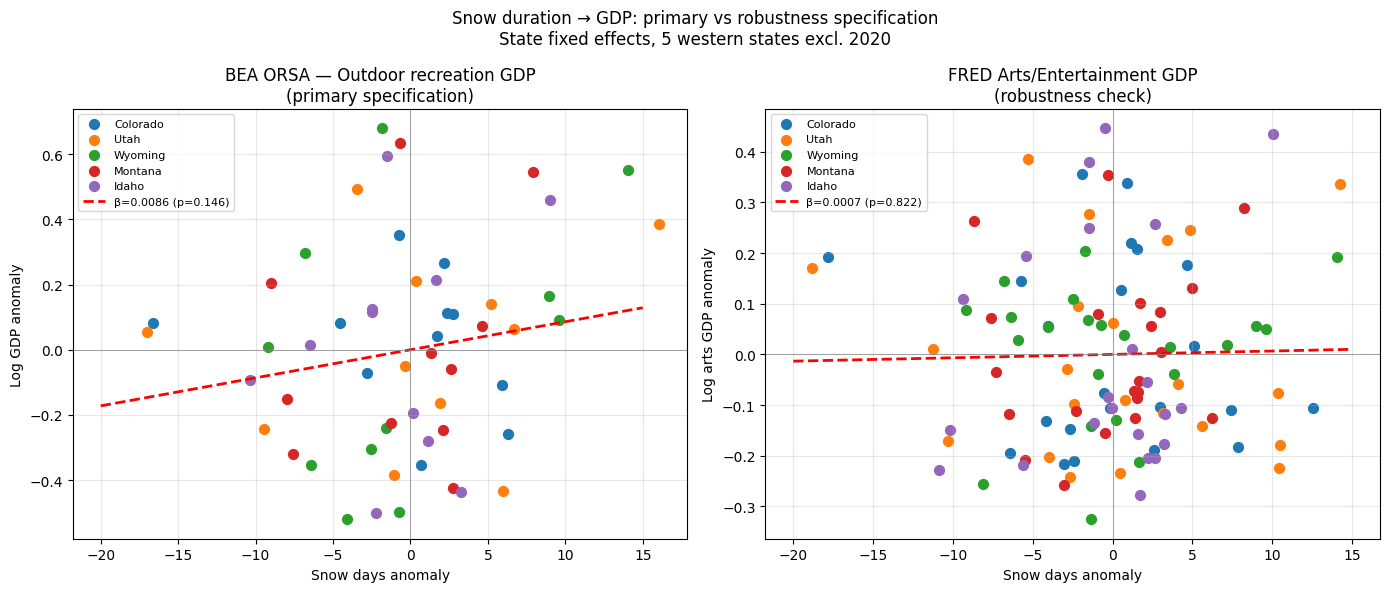

In [18]:
import os

fred_arts_files = {
    'colorado':  'COARTETRTACCFDQGSP',
    'utah':      'UTARTETRTACCFDQGSP',
    'wyoming':   'WYARTETRTACCFDQGSP',
    'montana':   'MTARTETRTACCFDQGSP',
    'idaho':     'IDARTETRTACCFDQGSP',
    'new_mexico':'NMARTETRTACCFDQGSP'
}

arts_records = []

for state, series in fred_arts_files.items():
    paths_to_try = [
        gdp_dir / f"arts_gdp_{state}.csv",
        gdp_dir / f"{series}.csv",
        gdp_dir / f"arts_{state}.csv"
    ]
    
    path = None
    for p in paths_to_try:
        if p.exists():
            path = p
            break
    
    if path is None:
        print(f"MISSING: arts GDP file for {state}")
        continue
    
    df = pd.read_csv(path)
    
    df.columns = ['date', 'arts_gdp']
    df['year']     = pd.to_datetime(df['date']).dt.year
    df['state']    = state
    df['arts_gdp'] = pd.to_numeric(df['arts_gdp'],
                                    errors='coerce')
    
    mean_val = df['arts_gdp'].mean()
    if mean_val > 100000:
        df['arts_gdp_millions'] = df['arts_gdp'] / 1000
    else:
        df['arts_gdp_millions'] = df['arts_gdp']
    
    arts_records.append(df[['state','year','arts_gdp_millions']])
    print(f"  {state:<12} loaded {len(df)} years, "
          f"mean=${df['arts_gdp_millions'].mean():.1f}M")

arts_panel = pd.concat(arts_records, ignore_index=True)

arts_panel = arts_panel[arts_panel['year'].between(2001, 2023)]
print(f"\nArts GDP panel shape: {arts_panel.shape}")

arts_pivot = arts_panel.pivot(
    index='year', columns='state',
    values='arts_gdp_millions').round(1)
print("\nArts/Entertainment GDP by state ($M):")
print(arts_pivot.to_string())

panel_arts = snow_panel.merge(
    arts_panel, on=['state','year'], how='inner'
)
panel_arts['log_arts_gdp'] = np.log(
    panel_arts['arts_gdp_millions']
)

print(f"\nMerged arts panel: {panel_arts.shape}")
print(f"Years: {panel_arts['year'].min()} - "
      f"{panel_arts['year'].max()}")

panel_arts['snow_demeaned'] = panel_arts.groupby(
    'state')['mean_snow_days'].transform(
    lambda x: x - x.mean()
)
panel_arts['arts_gdp_demeaned'] = panel_arts.groupby(
    'state')['log_arts_gdp'].transform(
    lambda x: x - x.mean()
)

mask_arts = (panel_arts['year'] != 2020) & \
            (panel_arts['state'] != 'new_mexico')

X_arts = panel_arts[mask_arts]['snow_demeaned'].values
y_arts = panel_arts[mask_arts]['arts_gdp_demeaned'].values

slope_a, _, r_a, p_a, se_a = stats.linregress(X_arts, y_arts)

mean_arts_gdp = panel_arts[mask_arts][
    'arts_gdp_millions'].mean()
dollar_arts = slope_a * mean_arts_gdp * 5

print(f"ROBUSTNESS CHECK: ARTS/ENTERTAINMENT GDP")
print(f"\n  β (snow days):   {slope_a:.4f}")
print(f"  R²:              {r_a**2:.3f}")
print(f"  p-value:         {p_a:.3f}")
print(f"  n observations:  {mask_arts.sum()}")
print(f"  Mean arts GDP:   ${mean_arts_gdp:.1f}M per state")
print(f"  +1 snow day →    ${dollar_arts:.1f}M across 5 states")


print(f"MODEL COMPARISON — ALL THREE GDP MEASURES")
print(f"\n{'Model':<35} {'β':>8} {'p':>8} {'n':>6} {'$/day':>10}")
print(f"  {'BEA ORSA (outdoor rec)':<33} "
      f"{0.0086:>8.4f} {0.146:>8.3f} {60:>6} "
      f"${12.3:>7.1f}M")
print(f"  {'FRED Arts/Ent (broader)':<33} "
      f"{slope_a:>8.4f} {p_a:>8.3f} "
      f"{mask_arts.sum():>6} "
      f"${dollar_arts:>7.1f}M")
print(f"\n  Both models show {'positive' if slope_a > 0 else 'negative'} "
      f"sign on snow coefficient")
if p_a < 0.05:
    print(f"  Arts/Ent result is SIGNIFICANT at 5% level ✓")
elif p_a < 0.10:
    print(f"  Arts/Ent result is SIGNIFICANT at 10% level ✓")
else:
    print(f"  Arts/Ent result not significant (p={p_a:.3f})")
print(f"  Consistent direction across both GDP definitions")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panel_bea  = panel[panel['state'] != 'new_mexico'].copy()
panel_bea['snow_dm'] = panel_bea.groupby(
    'state')['mean_snow_days'].transform(
    lambda x: x - x.mean())
panel_bea['gdp_dm'] = panel_bea.groupby(
    'state')['log_gdp'].transform(
    lambda x: x - x.mean())
mask_bea = panel_bea['year'] != 2020

for state in ['colorado','utah','wyoming','montana','idaho']:
    m = mask_bea & (panel_bea['state'] == state)
    axes[0].scatter(panel_bea[m]['snow_dm'],
                    panel_bea[m]['gdp_dm'],
                    label=state.title(),
                    color=colors_map[state], s=50)

x_line = np.linspace(-20, 15, 100)
axes[0].plot(x_line, 0.0086*x_line, 'r--',
             linewidth=2,
             label=f'β=0.0086 (p=0.146)')
axes[0].set_xlabel("Snow days anomaly")
axes[0].set_ylabel("Log GDP anomaly")
axes[0].set_title("BEA ORSA — Outdoor recreation GDP\n"
                  "(primary specification)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)

for state in ['colorado','utah','wyoming','montana','idaho']:
    m = mask_arts & (panel_arts['state'] == state)
    axes[1].scatter(
        panel_arts[m]['snow_demeaned'],
        panel_arts[m]['arts_gdp_demeaned'],
        label=state.title(),
        color=colors_map[state], s=50)

axes[1].plot(x_line, slope_a*x_line, 'r--',
             linewidth=2,
             label=f'β={slope_a:.4f} (p={p_a:.3f})')
axes[1].set_xlabel("Snow days anomaly")
axes[1].set_ylabel("Log arts GDP anomaly")
axes[1].set_title("FRED Arts/Entertainment GDP\n"
                  "(robustness check)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)

plt.suptitle("Snow duration → GDP: primary vs robustness specification\n"
             "State fixed effects, 5 western states excl. 2020",
             fontsize=12)
plt.tight_layout()
plt.savefig(state_dir / "robustness_comparison.png", dpi=150)
plt.show()